In [449]:
import dolfin
print("dolfin version:", dolfin.__version__)

dolfin version: 2019.1.0


In [450]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.patches as patches
from time import time
from itertools import product

from scipy.sparse import csr_matrix
from scipy.sparse import save_npz, load_npz

import os

from dolfin import *

In [451]:
from tqdm import tqdm  # pour les barres de progression dans les boucles

In [452]:
mesh_size = 200 
FE_type = "Lagrange"
degree = 2

mesh = UnitSquareMesh(mesh_size, mesh_size)
V = FunctionSpace(mesh, FE_type, degree)
print("Number of vertices:", mesh.num_vertices())

lines = {"mesh_size": mesh_size, "FE_type": FE_type, "degree": degree}
df_mesh_info = pd.DataFrame(lines, index=[0])

Number of vertices: 40401


In [453]:
# Boundary condition
class ConditionalBC(UserExpression):
    def eval(self, values, x):
        if x[0] < 0.1 and x[1] > 0.9:
            values[0] = 4.0
        elif x[1] < 0.1:
            values[0] = 1.0
        else:
            values[0] = 0.0
    def value_shape(self):
        return ()

u_D = ConditionalBC(degree=0)

def boundary(x, on_boundary):
    return on_boundary

bc = DirichletBC(V, u_D, boundary)

zero = Constant(0.0)
bc_zero = DirichletBC(V, zero, boundary)

# Define lifting
u_L = Function(V)
bc.apply(u_L.vector())  # fills u_L with the BC values

In [454]:
def heaviside(expr):
    return conditional(ge(expr, 0.0), 1.0, 0.0)

def get_conductivity(parameters):

    slope = parameters["slope"]; position = parameters["position"]; half_width = parameters["half_width"]; D_background = parameters["D_background"]; D_fracture = parameters["D_fracture"]
    x = SpatialCoordinate(mesh)
    x0 = x[0]
    x1 = x[1]

    norm_factor = Constant(100.0)


    arg1 = (position - half_width)/norm_factor - (slope/norm_factor * x0 + x1)
    arg2 = (slope/norm_factor * x0 + x1) - (position + half_width)/norm_factor
    arg3 = (slope/norm_factor * x0 + x1) - (position - half_width)/norm_factor
    arg4 = (position + half_width)/norm_factor - (slope/norm_factor * x0 + x1)

    K = D_background * (heaviside(arg1) + heaviside(arg2)) + D_fracture * heaviside(arg3) * heaviside(arg4)

    return K

In [455]:

def get_stiffness_and_load(parameters):
    K = get_conductivity(parameters)

    u = TrialFunction(V)
    v = TestFunction(V)

    a = inner(K*grad(u), grad(v))*dx
    L = Constant(0.0)*v*dx

    A = assemble(a)
    b = assemble(L)

    # Apply Dirichlet BCs to matrix and RHS vector
    b_mod = b.copy()
    A_uL = assemble(inner(K*grad(u_L), grad(v))*dx)
    b_mod.axpy(-1.0, A_uL)  # b_mod = b - A*u_L

    # Appliquer la BC homogène (u_0 = 0 sur bord)
    bc_zero.apply(A, b_mod)

    return A, b_mod

def PETSc_to_csr(A):
    """Convert a PETSc matrix to a SciPy CSR matrix."""

    # 1a) Grab the underlying PETSc Mat
    A_petsc = as_backend_type(A).mat()
    # 1b) Extract its CSR data (ai = row ptrs, aj = col inds, av = values)
    ai, aj, av = A_petsc.getValuesCSR()

    # 1c) Build a SciPy CSR matrix of the right shape
    n_rows, n_cols = A_petsc.getSize()
    A_csr = csr_matrix((av, aj, ai), shape=(n_rows, n_cols))

    return A_csr

def build_reduced_stiffness(A, V_r):
    A_csr = PETSc_to_csr(A)
    A_red = (V_r.T).dot(A_csr.dot(V_r))
    return A_red

def build_reduced_load(b, V_r):
    b_red = V_r.T.dot(b.get_local())
    return b_red

In [456]:
u_L_vect = np.array(u_L.vector().get_local())

In [457]:
example_parameters = {"slope": 40.0, "position": 70.0, "half_width": 5.0, "D_background": 100, "D_fracture": 1}
A_mu, b_mu = get_stiffness_and_load(example_parameters)
uh_HDM_sol = Function(V)
solve(A_mu, uh_HDM_sol.vector(), b_mu)
uh_HDM_sol_vec = np.array(uh_HDM_sol.vector().get_local()) + u_L_vect

In [458]:
uh_HDM_sol_vec.shape

(160801,)

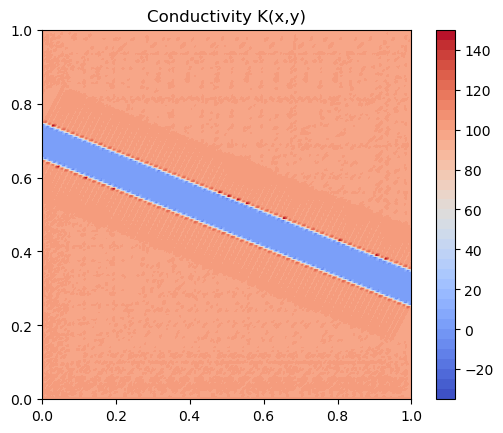

In [338]:
def plot_conductivity(parameters):
    K = get_conductivity(parameters)
    K_plot = project(K, V)

    p = plot(K_plot, cmap="coolwarm")
    plt.colorbar(p)
    plt.title("Conductivity K(x,y)")

K_test = get_conductivity(example_parameters)
plot_conductivity(example_parameters)

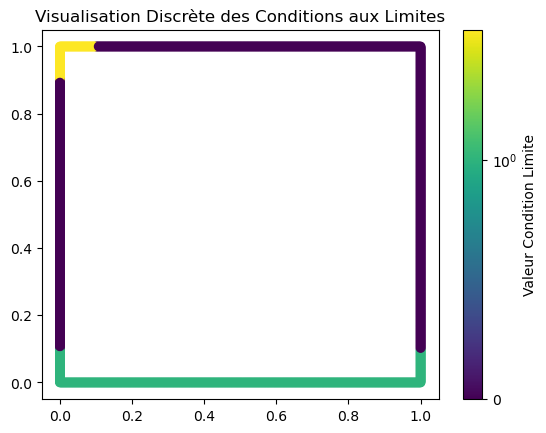

In [339]:

def plot_boundary_condition(cmap='viridis'):
    dof_coords = V.tabulate_dof_coordinates()
    boundary_dofs = bc.get_boundary_values().keys()
    x_b = np.array([dof_coords[dof][0] for dof in boundary_dofs])
    y_b = np.array([dof_coords[dof][1] for dof in boundary_dofs])
    v_b = np.array([u_L.vector()[dof] for dof in boundary_dofs])

    sc = plt.scatter(x_b, y_b, c=v_b, cmap=cmap, 
          norm=colors.SymLogNorm(linthresh=1e0, vmin=0.0, vmax=4.0))
    plt.colorbar(sc, label='Valeur Condition Limite')

plt.title("Visualisation Discrète des Conditions aux Limites")

plot_boundary_condition()

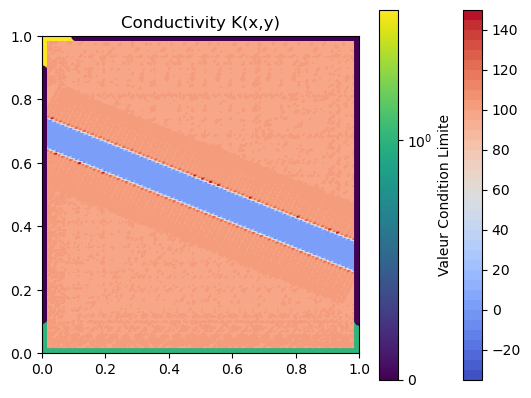

In [340]:
def plot_conductivity_boundary_condition(example_parameters):
    plot_conductivity(example_parameters)
    plot_boundary_condition() 
plot_conductivity_boundary_condition(example_parameters)

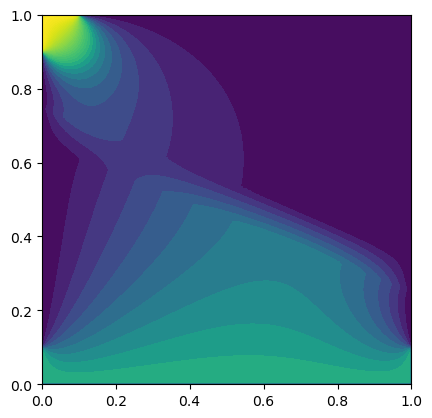

In [341]:

plot(uh_HDM_sol, 
          cmap="viridis", 
          norm=colors.SymLogNorm(linthresh=1e0, vmin=0.0, vmax=4.0))

In [459]:
N_dof = V.dim()
Ns = 30
U_snapshot = np.zeros((N_dof, Ns))
print("dimension de U_snapshot:", U_snapshot.shape)

dimension de U_snapshot: (160801, 30)


In [343]:
parameters_list = []
for i in tqdm(range(Ns), desc="Génération des Snapshots"):
    slope = np.random.uniform(20.0, 60.0)
    position = np.random.uniform(50.0, 90.0)
    half_width = np.random.uniform(3.0, 7.0)
    D_background = np.random.uniform(80.0, 120.0)
    D_fracture = np.random.uniform(0.5, 2.0)

    parameters = {"slope": slope, "position": position, "half_width": half_width, "D_background": D_background, "D_fracture": D_fracture}
    parameters_list.append(parameters)

    A_mu, b_mu = get_stiffness_and_load(parameters)
    uh_HDM_sol = Function(V)
    solve(A_mu, uh_HDM_sol.vector(), b_mu)
    uh_HDM_sol_vec = np.array(uh_HDM_sol.vector().get_local())
    U_snapshot[:, i] = uh_HDM_sol_vec
print(parameters_list)

Génération des Snapshots:   0%|          | 0/30 [00:00<?, ?it/s]

Calling FFC just-in-time (JIT) compiler, this may take some time.


Génération des Snapshots:   0%|          | 0/30 [00:05<?, ?it/s]


KeyboardInterrupt: 

In [460]:
def numpy_to_fenics(numpy_vec, V, u_L_vect):
    """
    Reconstruit un objet Function FEniCS à partir d'un vecteur Numpy.
    """
    # 1. On crée une "boîte" FEniCS vide sur ton maillage V
    u_reconstruit = Function(V)
    
    # 2. On fait l'opération inverse mathématiquement (- au lieu de +)
    valeurs_internes = numpy_vec - u_L_vect
    
    # 3. On injecte le tableau numpy dans le vecteur FEniCS (l'inverse de get_local)
    u_reconstruit.vector().set_local(valeurs_internes)
    
    return u_reconstruit

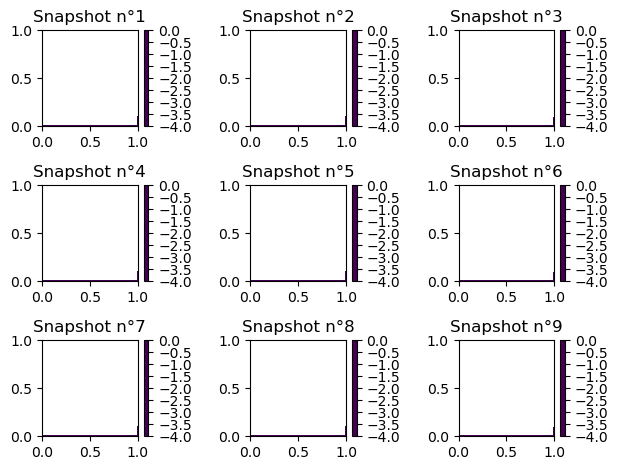

In [345]:
for i in range(9):
    vecteur_numpy = U_snapshot[:, i]    
    u_fenics = numpy_to_fenics(vecteur_numpy, V, u_L_vect)
    plt.subplot(3, 3, i + 1)
    p = plot(u_fenics, 
          cmap="viridis", 
          norm=colors.SymLogNorm(linthresh=1e0, vmin=0.0, vmax=4.0))
    plt.title(f"Snapshot n°{i+1}")
    plt.colorbar(p, fraction=0.046, pad=0.04) 
plt.tight_layout()
plt.show()

In [ ]:
U, S, Vt = np.linalg.svd(U_snapshot, full_matrices=False)



number of singular values: 30
U shape: (160801, 30)
S shape: (30,)
Vt shape: (30, 30)
Singular values: [1.18121011e+03 1.19577405e+02 8.77855483e+01 5.07574921e+01
 4.63915446e+01 3.68606517e+01 2.94709693e+01 2.38767560e+01
 2.06485501e+01 1.68581475e+01 1.42179954e+01 1.34925260e+01
 1.10025163e+01 1.00523118e+01 8.51377840e+00 6.68058301e+00
 6.17904410e+00 5.77902416e+00 5.46072845e+00 4.67405752e+00
 4.06004216e+00 3.37142182e+00 3.19391011e+00 2.91938100e+00
 2.64058704e+00 2.20775602e+00 2.01013605e+00 1.89724398e+00
 1.81225084e+00 1.05174617e+00]


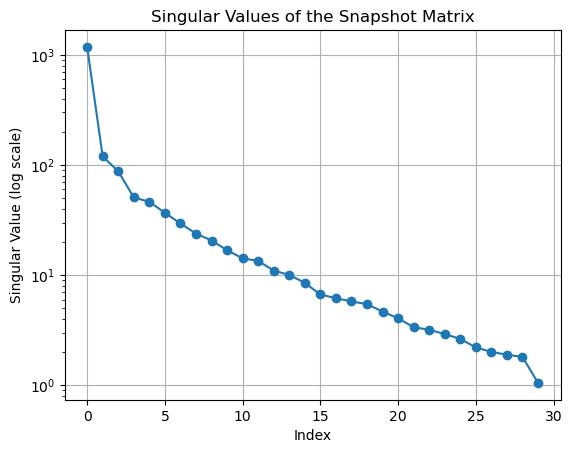

In [ ]:
print("number of singular values:", len(S))
print("U shape:", U.shape)
print("S shape:", S.shape)
print("Vt shape:", Vt.shape)
print("Singular values:", S)
plt.semilogy(S, marker='o')
plt.xlabel('Index')
plt.ylabel('Singular Value (log scale)')
plt.title('Singular Values of the Snapshot Matrix')
plt.grid()
plt.show()

In [ ]:
def plot_energy_contribution(S):
    energy = S**2
    print("Energy (squared singular values):", energy)
    cumulative_energy = np.cumsum(energy)
    print("Cumulative energy:", cumulative_energy)
    total_energy = cumulative_energy[-1]
    print("Total energy:", total_energy)
    energy_percentage = cumulative_energy / total_energy * 100
    print("Energy percentage:", energy_percentage)
    
    plt.figure(figsize=(8, 5))
    plt.plot(energy_percentage, marker='o')
    
    # --- LA CORRECTION EST ICI ---
    # On force l'axe Y à aller de 0 à 105% (ou 90 à 105% si tu préfères)
    plt.ylim(min(energy_percentage[0], 99), 100) 
    
    plt.xlabel('Number of Modes')
    plt.ylabel('Cumulative Energy (%)')
    plt.title('Cumulative Energy Contribution of Singular Values')
    plt.grid()
    plt.show()


Energy (squared singular values): [1.38615486e+06 1.25751180e+04 7.23548822e+03 3.23786123e+03
 2.18275568e+03 1.51504839e+03 1.17964349e+03 7.14023174e+02
 4.22353203e+02 3.64105704e+02 2.48201551e+02 1.94855563e+02
 1.24392267e+02 9.48102516e+01 6.84264237e+01 5.85640530e+01
 3.62673400e+01 2.63787947e+01 2.09192115e+01 1.74032938e+01
 1.55193244e+01 1.22119662e+01 1.02564837e+01 7.76255219e+00
 5.76096732e+00 4.77104240e+00 3.69205870e+00 2.28568396e+00
 2.16102960e+00 1.95928836e+00]
Cumulative energy: [1386154.85900232 1398729.9769955  1405965.46521258 1409203.32644469
 1411386.08212115 1412901.13051283 1414080.77399904 1414794.79717314
 1415217.1503765  1415581.25608055 1415829.45763202 1416024.31319522
 1416148.70546218 1416243.51571374 1416311.94213741 1416370.5061904
 1416406.77353038 1416433.15232506 1416454.07153656 1416471.47483033
 1416486.99415468 1416499.20612092 1416509.46260458 1416517.22515677
 1416522.98612409 1416527.75716649 1416531.44922519 1416533.73490915
 14165

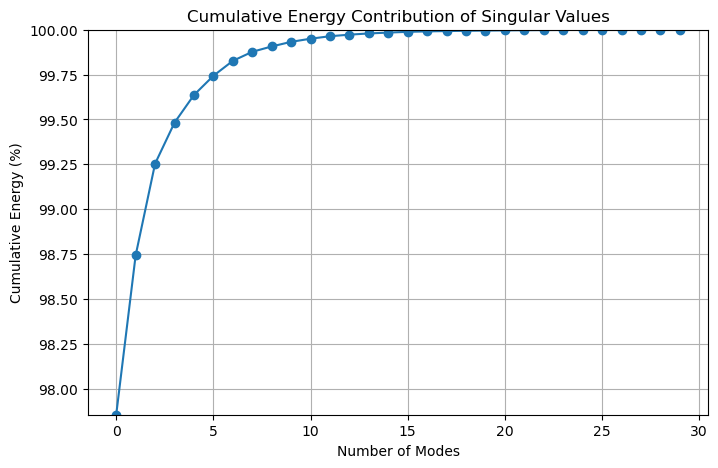

In [ ]:
plot_energy_contribution(S)

## Un premier test

Time for ROM solve: 0.18431401252746582 seconds
Time for full HDM solve: 1.5116121768951416 seconds


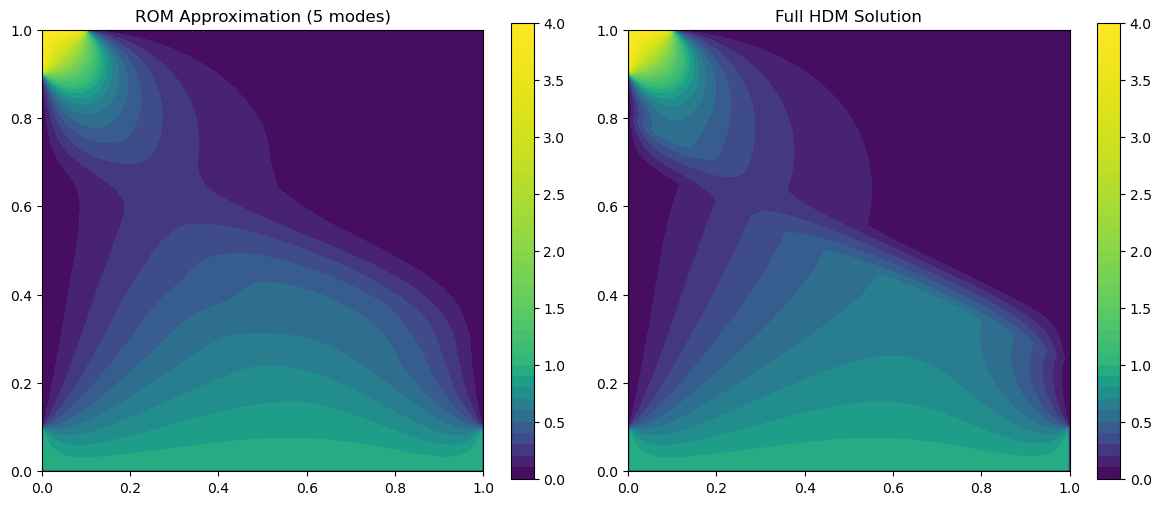

In [ ]:
test_parameters = {"slope": 45.0, "position": 75.0, "half_width": 5.0, "D_background": 100.0, "D_fracture": 1.0}
t = time()
A_test, b_test = get_stiffness_and_load(test_parameters)
V_r = U[:, :5]  # les 5 premiers modes
A_red = build_reduced_stiffness(A_test, V_r)
b_red = build_reduced_load(b_test, V_r)
u_red = np.linalg.solve(A_red, b_red)
u_approx = V_r.dot(u_red) + u_L_vect
u_approx_fenics = numpy_to_fenics(u_approx, V, u_L_vect)
print("Time for ROM solve:", time() - t, "seconds")
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
p1 = plot(u_approx_fenics, 
          cmap="viridis", 
          norm=colors.SymLogNorm(linthresh=1e0, vmin=0.0, vmax=4.0))
plt.colorbar(p1)
plt.title("ROM Approximation (5 modes)")
plt.subplot(1, 2, 2)
t = time()
A_full, b_full = get_stiffness_and_load(test_parameters)
u_full = Function(V)
solve(A_full, u_full.vector(), b_full)
u_full_vec = np.array(u_full.vector().get_local()) + u_L_vect
u_full_fenics = numpy_to_fenics(u_full_vec, V, u_L_vect)
print("Time for full HDM solve:", time() - t, "seconds")
p2 = plot(u_full_fenics, 
          cmap="viridis", 
          norm=colors.SymLogNorm(linthresh=1e0, vmin=0.0, vmax=4.0))
plt.colorbar(p2)
plt.title("Full HDM Solution")
plt.tight_layout()
plt.show()

## Qui est V1 ?

les colones de U sont les modes POD, on les multiplie par 1000 pour mieux les visualiser


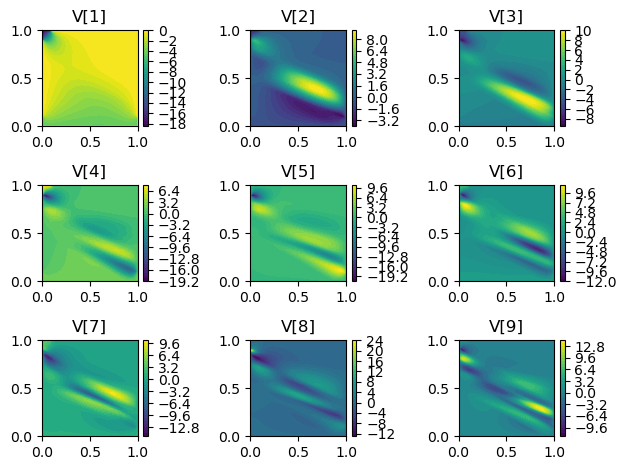

In [ ]:
print("les colones de U sont les modes POD, on les multiplie par 1000 pour mieux les visualiser")
for i in range(9):
    vecteur_numpy = U[:, i]*1000
    u_fenics = numpy_to_fenics(vecteur_numpy, V, u_L_vect)
    plt.subplot(3, 3, i + 1)
    p = plot(u_fenics)
    plt.title(f"V[{i+1}]")
    plt.colorbar(p, fraction=0.046, pad=0.04) 
plt.tight_layout()
plt.show()

In [346]:
def error_L2(u1, u2):
    """Calcule l'erreur relative L2 entre deux fonctions FEniCS."""
    diff = Function(V)
    diff.vector()[:] = u1.vector().get_local() - u2.vector().get_local()
    return norm(diff, 'L2') / norm(u1, 'L2')

Error with 1 modes: 1.1086e-01
Error with 2 modes: 1.1861e-01
Error with 3 modes: 8.5890e-02
Error with 4 modes: 8.0053e-02
Error with 5 modes: 8.0142e-02
Error with 6 modes: 8.1264e-02
Error with 7 modes: 8.3263e-02
Error with 8 modes: 8.3087e-02
Error with 9 modes: 8.0845e-02
Error with 10 modes: 7.1164e-02
Error with 11 modes: 7.0962e-02
Error with 12 modes: 6.5195e-02
Error with 13 modes: 6.5201e-02
Error with 14 modes: 6.1996e-02
Error with 15 modes: 5.6759e-02
Error with 16 modes: 5.3905e-02
Error with 17 modes: 4.6163e-02
Error with 18 modes: 4.6495e-02
Error with 19 modes: 4.6437e-02
Error with 20 modes: 4.6677e-02
Error with 21 modes: 4.6765e-02
Error with 22 modes: 4.7043e-02
Error with 23 modes: 4.7046e-02
Error with 24 modes: 4.6891e-02
Error with 25 modes: 4.7184e-02
Error with 26 modes: 4.7068e-02
Error with 27 modes: 4.7008e-02
Error with 28 modes: 4.6930e-02
Error with 29 modes: 4.6055e-02
Error with 30 modes: 4.4597e-02


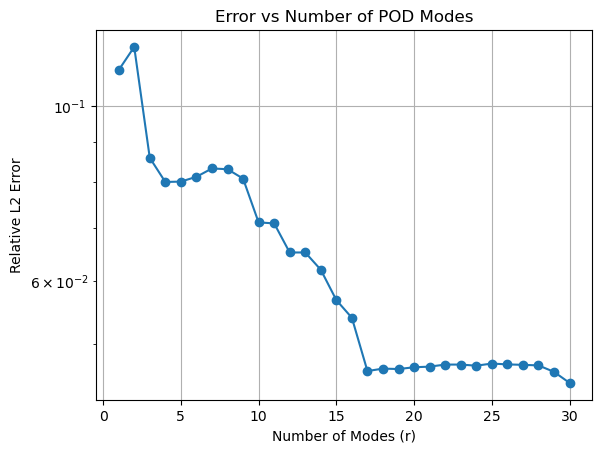

In [ ]:
error = np.zeros(30)
for r in range(1, 31):
    V_r = U[:, :r]
    A_red = build_reduced_stiffness(A_test, V_r)
    b_red = build_reduced_load(b_test, V_r)
    u_red = np.linalg.solve(A_red, b_red)
    u_approx = V_r.dot(u_red) + u_L_vect
    u_approx_fenics = numpy_to_fenics(u_approx, V, u_L_vect)
    error[r-1] = error_L2(u_full_fenics, u_approx_fenics)
    print(f"Error with {r} modes: {error[r-1]:.4e}")
plt.figure()
plt.semilogy(range(1, 31), error, marker='o')
plt.xlabel('Number of Modes (r)')
plt.ylabel('Relative L2 Error')
plt.title('Error vs Number of POD Modes')
plt.grid()
plt.show()

Error in A-norm with 1 modes: 2.0860e-02
Error in A-norm with 2 modes: 1.9656e-02
Error in A-norm with 3 modes: 1.9720e-02
Error in A-norm with 4 modes: 1.7210e-02
Error in A-norm with 5 modes: 1.6002e-02
Error in A-norm with 6 modes: 1.6241e-02
Error in A-norm with 7 modes: 1.6499e-02
Error in A-norm with 8 modes: 1.6291e-02
Error in A-norm with 9 modes: 1.6515e-02
Error in A-norm with 10 modes: 1.4839e-02
Error in A-norm with 11 modes: 1.4832e-02
Error in A-norm with 12 modes: 1.4858e-02
Error in A-norm with 13 modes: 1.5221e-02
Error in A-norm with 14 modes: 1.5919e-02
Error in A-norm with 15 modes: 1.5943e-02
Error in A-norm with 16 modes: 1.6704e-02
Error in A-norm with 17 modes: 1.6898e-02
Error in A-norm with 18 modes: 1.7120e-02
Error in A-norm with 19 modes: 1.7181e-02
Error in A-norm with 20 modes: 1.7350e-02
Error in A-norm with 21 modes: 1.7510e-02
Error in A-norm with 22 modes: 1.7517e-02
Error in A-norm with 23 modes: 1.7641e-02
Error in A-norm with 24 modes: 1.7640e-02
E

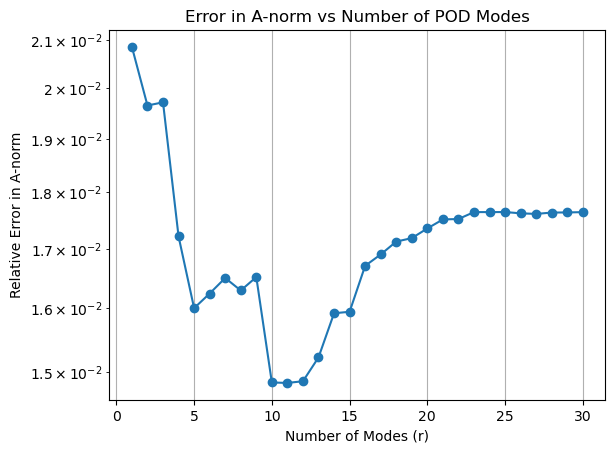

In [347]:
def normeA(u, A):
    """Calcule la norme induite par A de la fonction u (version 100% FEniCS)."""
    # 1. On crée un vecteur FEniCS vide de la même taille que u
    Au = Vector(u.vector()) 
    
    # 2. FEniCS fait la multiplication Matrice * Vecteur (Au = A * u)
    A.mult(u.vector(), Au)
    
    # 3. FEniCS fait le produit scalaire u^T * (Au)
    norme_A = np.sqrt(u.vector().inner(Au)) 
    
    return norme_A
def error_A_norm(u1, u2, A):
    """Calcule l'erreur relative dans la norme induite par A entre deux fonctions FEniCS."""
    diff = Function(V)
    diff.vector()[:] = u1.vector().get_local() - u2.vector().get_local()
    return normeA(diff, A) / normeA(u1, A)
error_A = np.zeros(30)
for r in range(1, 31):
    V_r = U[:, :r]
    A_red = build_reduced_stiffness(A_test, V_r)
    b_red = build_reduced_load(b_test, V_r)
    u_red = np.linalg.solve(A_red, b_red)
    u_approx = V_r.dot(u_red) + u_L_vect
    u_approx_fenics = numpy_to_fenics(u_approx, V, u_L_vect)
    error_A[r-1] = error_A_norm(u_full_fenics, u_approx_fenics, A_test)
    print(f"Error in A-norm with {r} modes: {error_A[r-1]:.4e}")


plt.figure()
plt.semilogy(range(1, 31), error_A, marker='o')
plt.xlabel('Number of Modes (r)')
plt.ylabel('Relative Error in A-norm')
plt.title('Error in A-norm vs Number of POD Modes')
plt.grid()
plt.show()

## CAS LINÉAIRE

Si on ne fait varier que $D_{\text{back}}$ et $D_{\text{fract}}$ dans la formule de $D_\mu(x, y)$ :

$D_\mu(x, y) = D_{\text{back}} \cdot \left( \sigma(-ax - y + (x_0 - w)) + \sigma(ax + y - (x_0 + w)) \right) + D_{\text{fract}} \cdot \sigma(-ax - y + (x_0 - w)) \cdot \sigma(ax + y - (x_0 + w))$

On se rend compte que la dépendance en les paramettre est linaire ainsi la matrice $A$ du probleme peut etre construit comme tel :

$\mathbf{A} = D_{\text{frac}} \cdot \mathbf{A}_{\text{frac}} + D_{\text{back}} \cdot \mathbf{A}_{\text{back}}$

Où $\mathbf{A}_{\text{frac}}$ et $\mathbf{A}_{\text{back}}$ ne sont calculées que une fois.


In [348]:
Ns_lineaire = 50
U_snapshot_lineaire = np.zeros((N_dof, Ns_lineaire))
print("dimension de U_snapshot:", U_snapshot_lineaire.shape)

dimension de U_snapshot: (160801, 50)


In [367]:
parameters_list_lineaire = []
for i in tqdm(range(Ns_lineaire), desc="Génération des Snapshots"):
    slope = 40.0
    position = 70.0
    half_width = 5.0
    D_background = np.random.uniform(80.0, 120.0)
    D_fracture = np.random.uniform(0.5, 2.0)

    parameters = {"slope": slope, "position": position, "half_width": half_width, "D_background": D_background, "D_fracture": D_fracture}
    parameters_list_lineaire.append(parameters)

    A_mu, b_mu = get_stiffness_and_load(parameters)
    uh_HDM_sol = Function(V)
    solve(A_mu, uh_HDM_sol.vector(), b_mu)
    uh_HDM_sol_vec = np.array(uh_HDM_sol.vector().get_local())
    U_snapshot_lineaire[:, i] = uh_HDM_sol_vec
print(parameters_list_lineaire)

Génération des Snapshots:   0%|          | 0/50 [00:00<?, ?it/s]

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


Génération des Snapshots:   2%|▏         | 1/50 [00:06<05:35,  6.85s/it]

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


Génération des Snapshots:   4%|▍         | 2/50 [00:14<05:38,  7.06s/it]

...

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


Génération des Snapshots:  98%|█████████▊| 49/50 [05:07<00:08,  8.52s/it]

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


Génération des Snapshots: 100%|██████████| 50/50 [05:15<00:00,  6.30s/it]

[{'slope': 40.0, 'position': 70.0, 'half_width': 5.0, 'D_background': 99.62082334598713, 'D_fracture': 1.879330114984661}, {'slope': 40.0, 'position': 70.0, 'half_width': 5.0, 'D_background': 90.99235247701475, 'D_fracture': 0.829259667449512}, {'slope': 40.0, 'position': 70.0, 'half_width': 5.0, 'D_background': 93.99325986541639, 'D_fracture': 1.0480539580501032}, {'slope': 40.0, 'position': 70.0, 'half_width': 5.0, 'D_background': 109.21168594616098, 'D_fracture': 0.5548092015910078}, {'slope': 40.0, 'position': 70.0, 'half_width': 5.0, 'D_background': 94.9228111927943, 'D_fracture': 0.8120269890407372}, {'slope': 40.0, 'position': 70.0, 'half_width': 5.0, 'D_background': 108.13448405634215, 'D_fracture': 1.1017129036618791}, {'slope': 40.0, 'position': 70.0, 'half_width': 5.0, 'D_background': 109.54907696103952, 'D_fracture': 1.2787180621585423}, {'slope': 40.0, 'position': 70.0, 'half_width': 5.0, 'D_background': 87.68954524517761, 'D_fracture': 1.6453985262170199}, {'slope': 40.0,

In [368]:
U_l, S_l, Vt_l = np.linalg.svd(U_snapshot_lineaire, full_matrices=False)

number of singular values: 50
U shape: (160801, 50)
S shape: (50,)
Vt shape: (50, 50)
Singular values: [1.54587601e+03 5.94385652e+00 3.32060328e-02 3.18470640e-03
 2.68148474e-05 2.01455350e-06 3.51292576e-08 1.39845900e-09
 4.90865091e-10 3.15558415e-11 2.69901246e-11 2.18172179e-11
 1.42570118e-11 1.00563004e-11 5.50063366e-12 3.85264761e-12
 3.83767643e-12 3.10043230e-12 2.06262449e-12 1.69160846e-12
 1.50122856e-12 1.42992672e-12 1.30914495e-12 1.10556312e-12
 1.02472834e-12 9.90073526e-13 8.60445884e-13 8.03963905e-13
 7.33646711e-13 6.83356691e-13 6.82645149e-13 6.56326621e-13
 5.49182730e-13 5.37361041e-13 4.71196849e-13 4.23902252e-13
 3.80115637e-13 3.57665765e-13 3.40201491e-13 3.27823399e-13
 3.10470722e-13 3.05731825e-13 2.96714580e-13 2.95725670e-13
 2.91881983e-13 2.88529684e-13 2.70150544e-13 2.50455930e-13
 2.31562385e-13 1.90152815e-13]


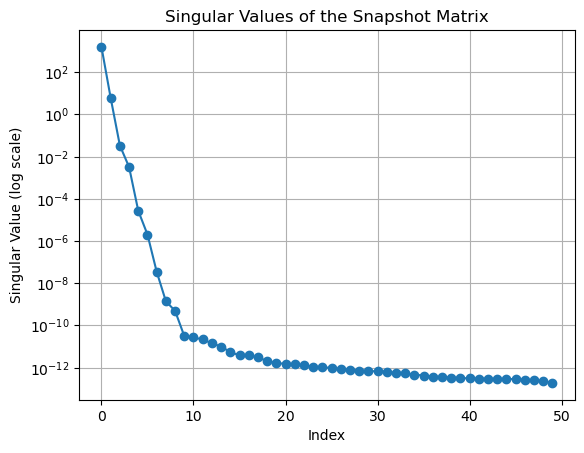

In [369]:
print("number of singular values:", len(S_l))
print("U shape:", U_l.shape)
print("S shape:", S_l.shape)
print("Vt shape:", Vt_l.shape)
print("Singular values:", S_l)
plt.semilogy(S_l, marker='o', label='Singular Values (Linear Snapshots)')
plt.xlabel('Index')
plt.ylabel('Singular Value (log scale)')
plt.title('Singular Values of the Snapshot Matrix')
plt.grid()
plt.show()

Energy (squared singular values): [2.38973264e+06 3.53294304e+01 1.10264061e-03 1.01423549e-05
 7.19036041e-10 4.05842582e-12 1.23406474e-15 1.95568759e-18
 2.40948537e-19 9.95771131e-22 7.28466825e-22 4.75990997e-22
 2.03262385e-22 1.01129178e-22 3.02569707e-23 1.48428936e-23
 1.47277604e-23 9.61268044e-24 4.25441979e-24 2.86153918e-24
 2.25368720e-24 2.04469042e-24 1.71386050e-24 1.22226982e-24
 1.05006818e-24 9.80245588e-25 7.40367119e-25 6.46357961e-25
 5.38237497e-25 4.66976368e-25 4.66004400e-25 4.30764634e-25
 3.01601671e-25 2.88756888e-25 2.22026470e-25 1.79693119e-25
 1.44487898e-25 1.27924799e-25 1.15737054e-25 1.07468181e-25
 9.63920690e-26 9.34719490e-26 8.80395422e-26 8.74536720e-26
 8.51950921e-26 8.32493785e-26 7.29813162e-26 6.27281728e-26
 5.36211382e-26 3.61580930e-26]
Cumulative energy: [2389732.63836211 2389767.96779247 2389767.96889511 2389767.96890525
 2389767.96890526 2389767.96890526 2389767.96890526 2389767.96890526
 2389767.96890526 2389767.96890526 2389767.96

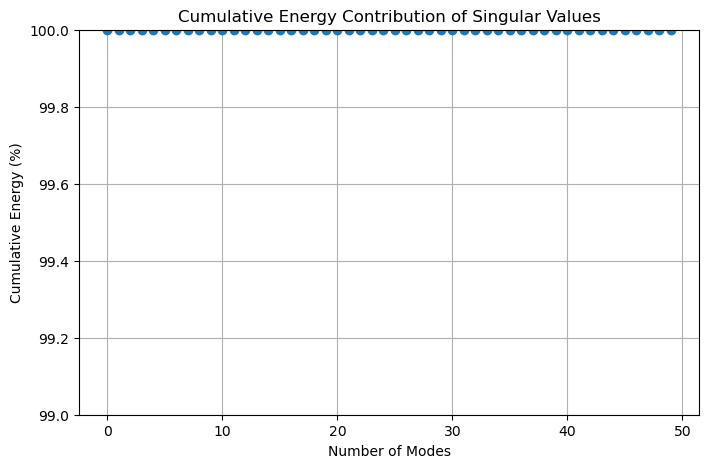

In [370]:
plot_energy_contribution(S_l)

In [371]:
N_test = 10
parameters_test_lineaire_list = []
for i in range(N_test):
    slope = 40.0
    position = 70.0
    half_width = 5.0
    D_background = np.random.uniform(80.0, 120.0)
    D_fracture = np.random.uniform(0.5, 2.0)

    parameters = {"slope": slope, "position": position, "half_width": half_width, "D_background": D_background, "D_fracture": D_fracture}
    parameters_test_lineaire_list.append(parameters)

In [412]:
Ns_lineaire_range = [1, 3, 6, 9, 20, 50]#range(1, Ns_lineaire+1, 10)
error_A_lineaire = np.zeros(len(Ns_lineaire_range))
time_linear = np.zeros(len(Ns_lineaire_range))


# ==========================================
# 0. TOUR DE CHAUFFE (WARM-UP)
# On force l'ordinateur à tout initialiser (FEniCS + NumPy) sur le plus gros cas pour preparer le cache et les compilations JIT, afin d'avoir des mesures de temps plus stables et représentatives lors du benchmark.
# ==========================================
print("Tour de chauffe en cours (compilation JIT et initialisation mémoire)...")
params_warmup = parameters_test_lineaire_list[0]
A_warmup, b_warmup = get_stiffness_and_load(params_warmup)
u_full_warmup = Function(V)
solve(A_warmup, u_full_warmup.vector(), b_warmup) # Chauffe FEniCS

r_max = Ns_lineaire_range[-1] # On prend le plus gros r (ex: 50)
V_r_warmup = U_l[:, :r_max]
A_red_warmup = build_reduced_stiffness(A_warmup, V_r_warmup) # Chauffe la projection
b_red_warmup = build_reduced_load(b_warmup, V_r_warmup)
u_red_warmup = np.linalg.solve(A_red_warmup, b_red_warmup)   # Chauffe le solveur NumPy
_ = V_r_warmup.dot(u_red_warmup) + u_L_vect                  # Chauffe le produit matriciel
print("Tour de chauffe terminé ! Lancement du benchmark...")
# ==========================================
A_test_linear_list = []
b_test_linear_list = []
HF_sol_linear_list = []
for i, params in enumerate(parameters_test_lineaire_list):
    A_test, b_test = get_stiffness_and_load(params)
    A_test_linear_list.append(A_test)
    b_test_linear_list.append(b_test)
    
    # Résolution Haute Fidélité (FOM) de référence
    u_full = Function(V)
    solve(A_test, u_full.vector(), b_test) 
    HF_sol_linear_list.append(u_full)




for j, r in enumerate(tqdm(Ns_lineaire_range, desc="Testing ROM with linear snapshots")):
    for i, params in enumerate(parameters_test_lineaire_list):

        u_full = HF_sol_linear_list[i]
        V_r = U_l[:, :r]

        # ==========================================
        # DÉBUT DU CHRONO : PHASE ONLINE ROM STRICTE
        # ==========================================
        t0 = time() 
        A_test, b_test = get_stiffness_and_load(params)
        A_red = build_reduced_stiffness(A_test, V_r)
        b_red = build_reduced_load(b_test, V_r)
        
        u_red = np.linalg.solve(A_red, b_red)
        u_approx = V_r.dot(u_red) + u_L_vect
        
        
        t1 = time() 
        # ==========================================
        # FIN DU CHRONO
        # ==========================================
        
        # 2. POST-TRAITEMENT ET ERREUR (Hors chrono ROM)
        u_approx_fenics = numpy_to_fenics(u_approx, V, u_L_vect)
        error_A_lineaire[j] += error_A_norm(u_full, u_approx_fenics, A_test)
        
        time_linear[j] += (t1 - t0)

    # Moyenne sur les N_test paramètres
    error_A_lineaire[j] /= len(parameters_test_lineaire_list) 
    time_linear[j] /= len(parameters_test_lineaire_list)
    
    print(f"Error in A-norm with {r} modes: {error_A_lineaire[j]:.4e} | Time: {time_linear[j]:.4e} s")


Tour de chauffe en cours (compilation JIT et initialisation mémoire)...
Tour de chauffe terminé ! Lancement du benchmark...


Testing ROM with linear snapshots:  17%|█▋        | 1/6 [00:02<00:11,  2.29s/it]

Error in A-norm with 1 modes: 2.2099e-04 | Time: 2.1414e-01 s


Testing ROM with linear snapshots:  33%|███▎      | 2/6 [00:04<00:09,  2.42s/it]

Error in A-norm with 3 modes: 1.7621e-07 | Time: 2.3569e-01 s


...

Error in A-norm with 9 modes: 3.3296e-14 | Time: 2.4301e-01 s


Testing ROM with linear snapshots:  83%|████████▎ | 5/6 [00:12<00:02,  2.60s/it]

Error in A-norm with 20 modes: 2.8949e-14 | Time: 2.5571e-01 s


Testing ROM with linear snapshots: 100%|██████████| 6/6 [00:26<00:00,  4.36s/it]

Error in A-norm with 50 modes: 3.4188e-14 | Time: 1.3292e+00 s


In [410]:
HF_compution_time = 0
for i, params in enumerate(parameters_test_lineaire_list):
    A_test, b_test = get_stiffness_and_load(params)
    u_full = Function(V)
    t = time()
    solve(A_test, u_full.vector(), b_test)
    HF_compution_time += time() - t
HF_compution_time /= N_test
print(f"Average time for HF computation: {HF_compution_time:.4f} seconds")


Average time for HF computation: 2.1861 seconds


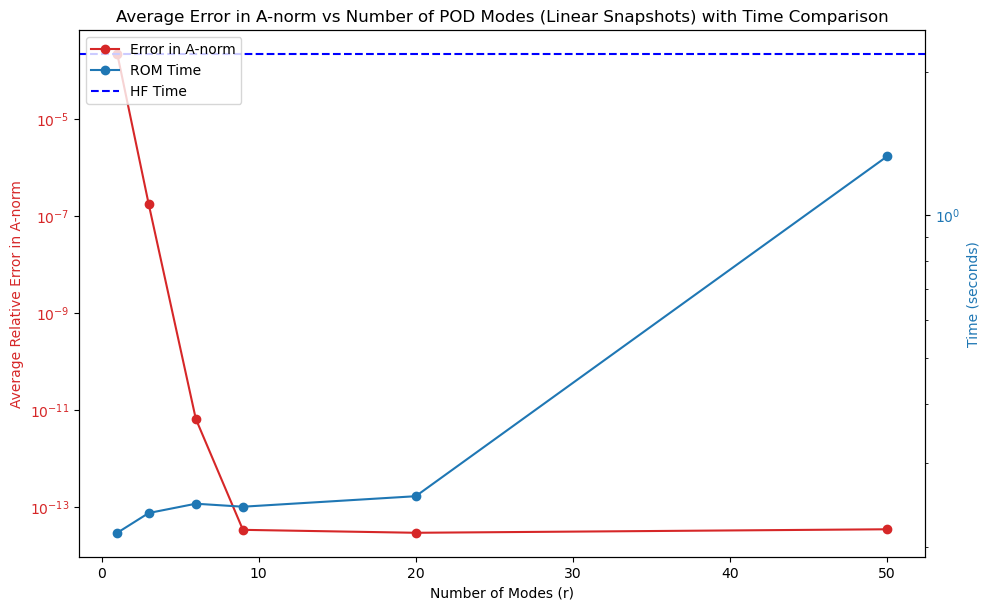

In [413]:

# Créer la figure et l'axe principal pour l'erreur
fig, ax1 = plt.subplots(figsize=(10, 6))
# Plotter l'erreur en norme A sur l'axe principal (gauche)
color = 'tab:red'
ax1.set_xlabel('Number of Modes (r)')
ax1.set_ylabel('Average Relative Error in A-norm', color=color)
ax1.semilogy(Ns_lineaire_range, error_A_lineaire, marker='o', color=color, label='Error in A-norm')
ax1.tick_params(axis='y', labelcolor=color)
# Créer un deuxième axe y partagant la même échelle x
ax2 = ax1.twinx()
# Plotter le temps sur le deuxième axe (droite)
color = 'tab:blue'
ax2.set_ylabel('Time (seconds)', color=color)
ax2.semilogy(Ns_lineaire_range, time_linear, marker='o', color=color, label='ROM Time')
ax2.axhline(y=HF_compution_time, color='b', linestyle='--', label='HF Time')
ax2.tick_params(axis='y', labelcolor=color)
# Ajouter une légende
fig.tight_layout()  # Ajuster la disposition pour éviter les chevauchements
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
# Ajouter un titre
plt.title('Average Error in A-norm vs Number of POD Modes (Linear Snapshots) with Time Comparison')
# Afficher le graphique
plt.show()


évolution de la solution approchée en fonction du nombre de modes POD :


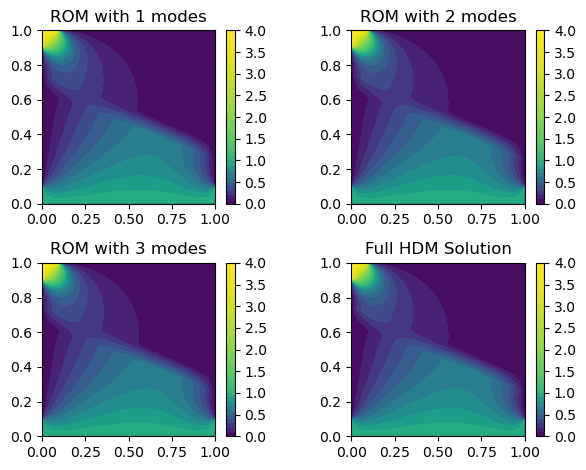

In [396]:
print("évolution de la solution approchée en fonction du nombre de modes POD :")
for r in range(3):
    V_r = U_l[:, :r+1]
    A_test = A_test_linear_list[0]  # On prend le premier cas de test pour la visualisation
    b_test = b_test_linear_list[0]  # On prend le premier cas de test pour la visualisation
    A_red = build_reduced_stiffness(A_test, V_r)
    b_red = build_reduced_load(b_test, V_r)
    u_red = np.linalg.solve(A_red, b_red)
    u_approx = V_r.dot(u_red) + u_L_vect
    u_approx_fenics = numpy_to_fenics(u_approx, V, u_L_vect)
    
    plt.subplot(2, 2, r + 1)
    p = plot(u_approx_fenics, 
          cmap="viridis", 
          norm=colors.SymLogNorm(linthresh=1e0, vmin=0.0, vmax=4.0))
    plt.title(f"ROM with {r+1} modes")
    plt.colorbar(p, fraction=0.046, pad=0.04)
plt.subplot(2, 2, 4)
u_full = HF_sol_linear_list[0]  # Solution HDM de référence pour le même cas de test
p = plot(u_full, 
          cmap="viridis", 
          norm=colors.SymLogNorm(linthresh=1e0, vmin=0.0, vmax=4.0))
plt.title("Full HDM Solution")
plt.colorbar(p, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

Maintenant essayions de chercher $\mathbf{A}_{\text{frac}}$ et $\mathbf{A}_{\text{back}}$

In [397]:
p_f = {"slope": 40.0, "position": 70.0, "half_width": 5.0, "D_background": 0, "D_fracture": 1.0}
p_b = {"slope": 40.0, "position": 70.0, "half_width": 5.0, "D_background": 1.0, "D_fracture": 0}
A_frac, b_frac = get_stiffness_and_load(p_f)
A_back, b_back = get_stiffness_and_load(p_b)

In [414]:
error_A_lineaire_sep = np.zeros(len(Ns_lineaire_range))
time_linear_sep = np.zeros(len(Ns_lineaire_range))


# ==========================================
# 0. TOUR DE CHAUFFE (WARM-UP)
# On force l'ordinateur à tout initialiser (FEniCS + NumPy) sur le plus gros cas pour preparer le cache et les compilations JIT, afin d'avoir des mesures de temps plus stables et représentatives lors du benchmark.
# ==========================================
print("Tour de chauffe en cours (compilation JIT et initialisation mémoire)...")
params_warmup = parameters_test_lineaire_list[0]
A_warmup, b_warmup = get_stiffness_and_load(params_warmup)
u_full_warmup = Function(V)
solve(A_warmup, u_full_warmup.vector(), b_warmup) # Chauffe FEniCS

r_max = Ns_lineaire_range[-1] # On prend le plus gros r (ex: 50)
V_r_warmup = U_l[:, :r_max]
A_frac_red_warmup = build_reduced_stiffness(A_frac, V_r_warmup) # Chauffe la projection
b_frac_red_warmup = build_reduced_load(b_frac, V_r_warmup)
A_back_red_warmup = build_reduced_stiffness(A_back, V_r_warmup)
b_back_red_warmup = build_reduced_load(b_back, V_r_warmup)
A_red_warmup = p_b["D_background"] * A_back_red_warmup + p_f["D_fracture"] * A_frac_red_warmup
b_red_warmup = p_b["D_background"] * b_back_red_warmup + p_f["D_fracture"] * b_frac_red_warmup
u_red_warmup = np.linalg.solve(A_red_warmup, b_red_warmup)   # Chauffe le solveur NumPy
_ = V_r_warmup.dot(u_red_warmup) + u_L_vect                  # Chauffe le produit matriciel
print("Tour de chauffe terminé ! Lancement du benchmark...")
# ==========================================
A_test_linear_list = []
b_test_linear_list = []
HF_sol_linear_list = []
for i, params in enumerate(parameters_test_lineaire_list):
    A_test, b_test = get_stiffness_and_load(params)
    A_test_linear_list.append(A_test)
    b_test_linear_list.append(b_test)
    
    # Résolution Haute Fidélité (FOM) de référence
    u_full = Function(V)
    solve(A_test, u_full.vector(), b_test) 
    HF_sol_linear_list.append(u_full)




for j, r in enumerate(tqdm(Ns_lineaire_range, desc="Testing ROM with linear snapshots")):
    for i, params in enumerate(parameters_test_lineaire_list):
        A_test = A_test_linear_list[i]#pour la norme A
        u_full = HF_sol_linear_list[i]
        V_r = U_l[:, :r]
        A_frac_red = build_reduced_stiffness(A_frac, V_r)
        b_frac_red = build_reduced_load(b_frac, V_r)
        A_back_red = build_reduced_stiffness(A_back, V_r)
        b_back_red = build_reduced_load(b_back, V_r)
        # ==========================================
        # DÉBUT DU CHRONO : PHASE ONLINE ROM STRICTE
        # ==========================================
        t0 = time() 

        A_red = params["D_background"] * A_back_red + params["D_fracture"] * A_frac_red
        b_red = params["D_background"] * b_back_red + params["D_fracture"] * b_frac_red
        
        u_red = np.linalg.solve(A_red, b_red)
        u_approx = V_r.dot(u_red) + u_L_vect
        
        t1 = time() 
        # ==========================================
        # FIN DU CHRONO
        # ==========================================
        
        # 2. POST-TRAITEMENT ET ERREUR (Hors chrono ROM)
        u_approx_fenics = numpy_to_fenics(u_approx, V, u_L_vect)
        error_A_lineaire_sep[j] += error_A_norm(u_full, u_approx_fenics, A_test)
        
        time_linear_sep[j] += (t1 - t0)

    # Moyenne sur les N_test paramètres
    error_A_lineaire_sep[j] /= len(parameters_test_lineaire_list) 
    time_linear_sep[j] /= len(parameters_test_lineaire_list)
    
    print(f"Error in A-norm with {r} modes: {error_A_lineaire_sep[j]:.4e} | Time: {time_linear_sep[j]:.4e} s")

Tour de chauffe en cours (compilation JIT et initialisation mémoire)...
Tour de chauffe terminé ! Lancement du benchmark...


Testing ROM with linear snapshots:  17%|█▋        | 1/6 [00:00<00:02,  2.18it/s]

Error in A-norm with 1 modes: 2.2099e-04 | Time: 4.4177e-04 s


Testing ROM with linear snapshots:  33%|███▎      | 2/6 [00:01<00:02,  1.59it/s]

Error in A-norm with 3 modes: 1.7621e-07 | Time: 5.5137e-03 s


...

Error in A-norm with 9 modes: 5.0520e-14 | Time: 7.0930e-03 s


Testing ROM with linear snapshots:  83%|████████▎ | 5/6 [00:04<00:00,  1.06it/s]

Error in A-norm with 20 modes: 4.7659e-14 | Time: 2.7544e-03 s


Testing ROM with linear snapshots: 100%|██████████| 6/6 [00:27<00:00,  4.54s/it]

Error in A-norm with 50 modes: 5.0788e-14 | Time: 2.1166e-03 s


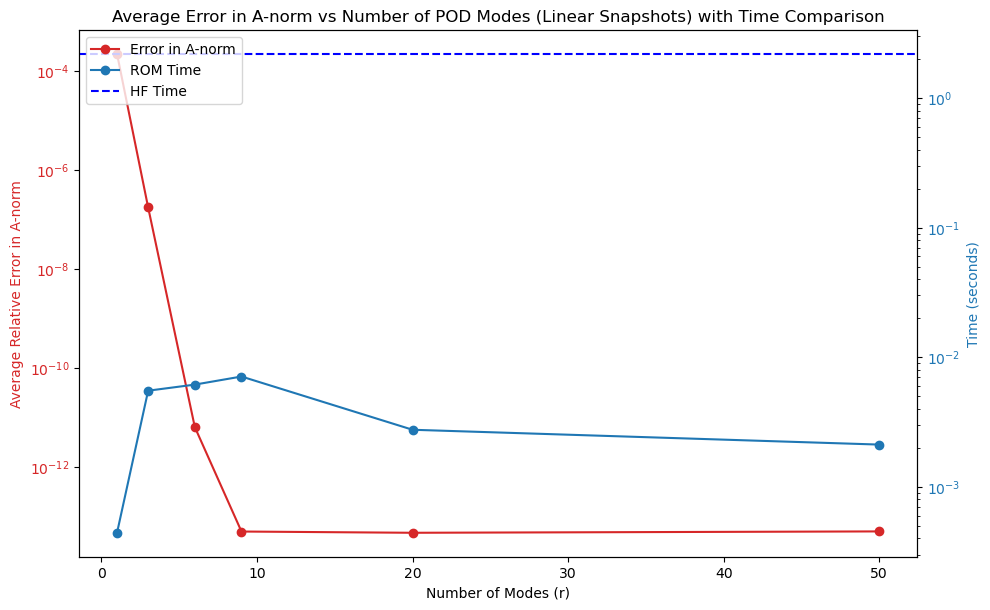

In [415]:
# Créer la figure et l'axe principal pour l'erreur
fig, ax1 = plt.subplots(figsize=(10, 6))
# Plotter l'erreur en norme A sur l'axe principal (gauche)
color = 'tab:red'
ax1.set_xlabel('Number of Modes (r)')
ax1.set_ylabel('Average Relative Error in A-norm', color=color)
ax1.semilogy(Ns_lineaire_range, error_A_lineaire_sep, marker='o', color=color, label='Error in A-norm')
ax1.tick_params(axis='y', labelcolor=color)
# Créer un deuxième axe y partagant la même échelle x
ax2 = ax1.twinx()
# Plotter le temps sur le deuxième axe (droite)
color = 'tab:blue'
ax2.set_ylabel('Time (seconds)', color=color)
ax2.semilogy(Ns_lineaire_range, time_linear_sep, marker='o', color=color, label='ROM Time')
ax2.axhline(y=HF_compution_time, color='b', linestyle='--', label='HF Time')
ax2.tick_params(axis='y', labelcolor=color)
# Ajouter une légende
fig.tight_layout()  # Ajuster la disposition pour éviter les chevauchements
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
# Ajouter un titre
plt.title('Average Error in A-norm vs Number of POD Modes (Linear Snapshots) with Time Comparison')
# Afficher le graphique
plt.show()

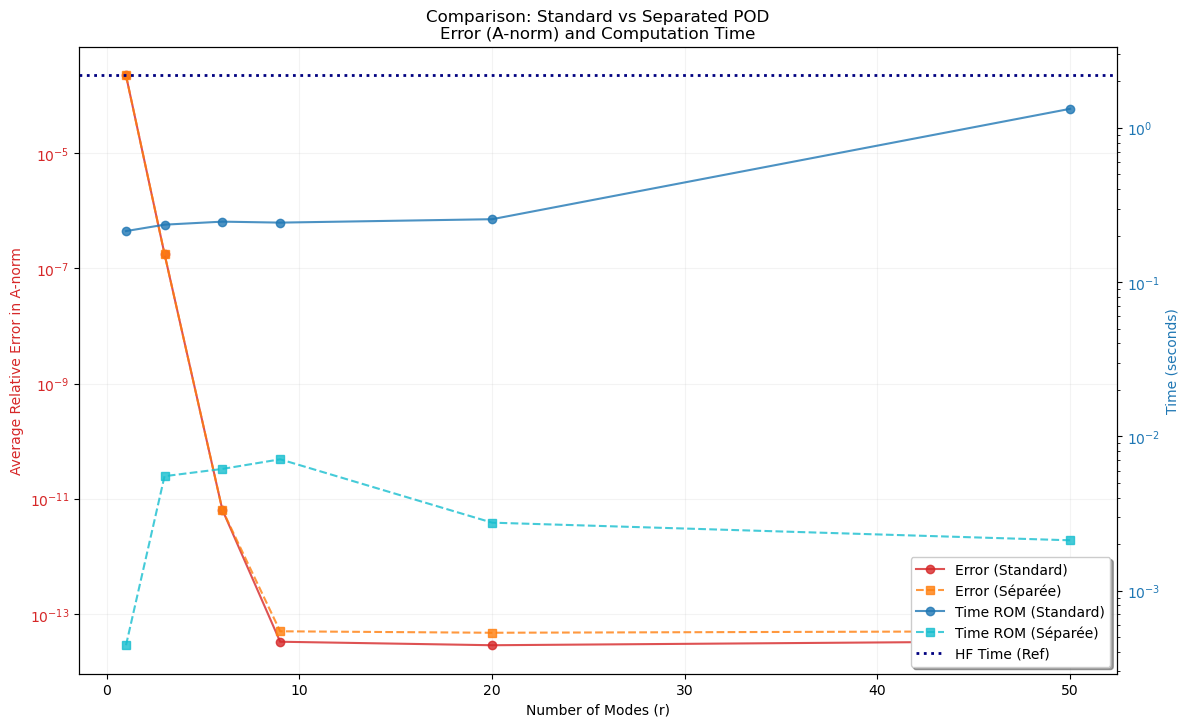

In [416]:
fig, ax1 = plt.subplots(figsize=(12, 7))

# --- AXE GAUCHE : ERREURS ---
ax1.set_xlabel('Number of Modes (r)')
ax1.set_ylabel('Average Relative Error in A-norm', color='tab:red')

# Erreur "Standard"
ax1.semilogy(Ns_lineaire_range, error_A_lineaire, 
             marker='o', color='tab:red', linestyle='-', alpha=0.8, label='Error (Standard)')
# Erreur "Séparée" (_sep)
ax1.semilogy(Ns_lineaire_range, error_A_lineaire_sep, 
             marker='s', color='tab:orange', linestyle='--', alpha=0.8, label='Error (Séparée)')

ax1.tick_params(axis='y', labelcolor='tab:red')
ax1.grid(True, which="both", ls="-", alpha=0.15)

# --- AXE DROITE : TEMPS ---
ax2 = ax1.twinx()
ax2.set_ylabel('Time (seconds)', color='tab:blue')

# Temps ROM "Standard"
ax2.semilogy(Ns_lineaire_range, time_linear, 
             marker='o', color='tab:blue', linestyle='-', alpha=0.8, label='Time ROM (Standard)')
# Temps ROM "Séparé" (_sep)
ax2.semilogy(Ns_lineaire_range, time_linear_sep, 
             marker='s', color='tab:cyan', linestyle='--', alpha=0.8, label='Time ROM (Séparée)')

# Temps Haute Fidélité (Référence horizontale)
ax2.axhline(y=HF_compution_time, color='navy', linestyle=':', linewidth=2, label='HF Time (Ref)')

ax2.tick_params(axis='y', labelcolor='tab:blue')

# --- LÉGENDE ET FINITIONS ---
fig.tight_layout()
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# On place la légende à l'endroit le plus vide (souvent center right ou upper right)
ax2.legend(lines1 + lines2, labels1 + labels2, loc='best', frameon=True, shadow=True)

plt.title('Comparison: Standard vs Separated POD\nError (A-norm) and Computation Time')
plt.show()

## CAS NON-LINÉAIRE

Maintenant faisons varier $a$, $w$ et $x_0$ plutot que $D_{\text{back}}$ et $D_{\text{fract}}$ dans la formule de $D_\mu(x, y)$ :

$D_\mu(x, y) = D_{\text{back}} \cdot \left( \sigma(-ax - y + (x_0 - w)) + \sigma(ax + y - (x_0 + w)) \right) + D_{\text{fract}} \cdot \sigma(-ax - y + (x_0 - w)) \cdot \sigma(ax + y - (x_0 + w))$

Cette fois-ci la dépendance n'est absolument pas lineaire.


In [ ]:
Ns_non_lineaire = 200
U_snapshot_non_lineaire = np.zeros((N_dof, Ns_non_lineaire))
print("dimension de U_snapshot:", U_snapshot_non_lineaire.shape)

dimension de U_snapshot: (160801, 200)


In [ ]:
parameters_list_non_lineaire = []
for i in tqdm(range(Ns_non_lineaire), desc="Génération des Snapshots"):
    slope = np.random.uniform(20.0, 60.0)
    position = np.random.uniform(50.0, 90.0)
    half_width = np.random.uniform(3.0, 7.0)
    D_background = 100.0
    D_fracture = 1.0

    parameters = {"slope": slope, "position": position, "half_width": half_width, "D_background": D_background, "D_fracture": D_fracture}
    parameters_list_non_lineaire.append(parameters)

    A_mu, b_mu = get_stiffness_and_load(parameters)
    uh_HDM_sol = Function(V)
    solve(A_mu, uh_HDM_sol.vector(), b_mu)
    uh_HDM_sol_vec = np.array(uh_HDM_sol.vector().get_local())
    U_snapshot_non_lineaire[:, i] = uh_HDM_sol_vec
print(parameters_list_non_lineaire)

In [ ]:
U_nl, S_nl, Vt_nl = np.linalg.svd(U_snapshot_non_lineaire, full_matrices=False)

number of singular values: 200
U shape: (160801, 200)
S shape: (200,)
Vt shape: (200, 200)
Singular values: [3.04781964e+03 3.21672273e+02 2.40793681e+02 1.44003474e+02
 1.13425667e+02 1.08871440e+02 9.09719198e+01 6.56052563e+01
 5.61540031e+01 4.85259890e+01 4.65013871e+01 3.75096228e+01
 3.17757933e+01 3.09772583e+01 2.86025643e+01 2.56945895e+01
 2.36260757e+01 2.18059857e+01 1.97931123e+01 1.74116952e+01
 1.62306135e+01 1.50355443e+01 1.35699230e+01 1.31541424e+01
 1.17622896e+01 1.13793465e+01 1.06595931e+01 9.93753463e+00
 9.43080031e+00 8.67116352e+00 8.58291193e+00 8.14434770e+00
 7.70460498e+00 7.29486206e+00 7.20459999e+00 6.97645210e+00
 6.78041330e+00 6.47584890e+00 6.19087030e+00 5.75858280e+00
 5.52665450e+00 5.26858139e+00 5.11207281e+00 4.79338401e+00
 4.75563247e+00 4.52165808e+00 4.47018984e+00 4.37807077e+00
 4.02931166e+00 3.96700468e+00 3.91011521e+00 3.78886037e+00
 3.65647873e+00 3.59306424e+00 3.46081785e+00 3.37237507e+00
 3.20517378e+00 3.15530517e+00 3.04376

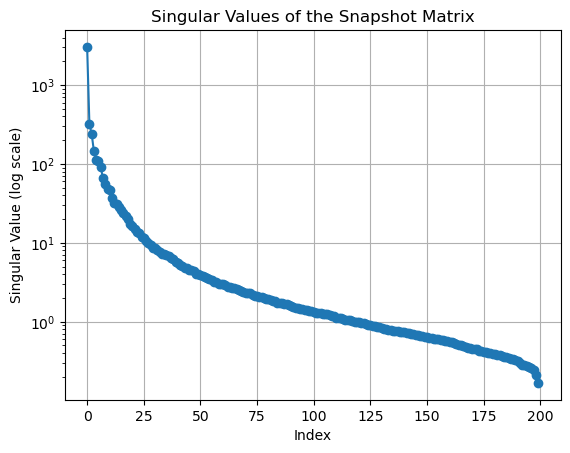

In [ ]:
print("number of singular values:", len(S_nl))
print("U shape:", U_nl.shape)
print("S shape:", S_nl.shape)
print("Vt shape:", Vt_nl.shape)
print("Singular values:", S_nl)
plt.semilogy(S_nl, marker='o', label='Singular Values (Linear Snapshots)')
plt.xlabel('Index')
plt.ylabel('Singular Value (log scale)')
plt.title('Singular Values of the Snapshot Matrix')
plt.grid()
plt.show()

Energy (squared singular values): [9.28920458e+06 1.03473051e+05 5.79815966e+04 2.07370006e+04
 1.28653820e+04 1.18529905e+04 8.27589019e+03 4.30404966e+03
 3.15327206e+03 2.35477161e+03 2.16237900e+03 1.40697180e+03
 1.00970104e+03 9.59590533e+02 8.18106683e+02 6.60211931e+02
 5.58191451e+02 4.75501012e+02 3.91767294e+02 3.03167131e+02
 2.63432814e+02 2.26067594e+02 1.84142810e+02 1.73031461e+02
 1.38351456e+02 1.29489526e+02 1.13626924e+02 9.87545945e+01
 8.89399944e+01 7.51890768e+01 7.36663772e+01 6.63303994e+01
 5.93609378e+01 5.32150124e+01 5.19062610e+01 4.86708839e+01
 4.59740045e+01 4.19366190e+01 3.83268750e+01 3.31612759e+01
 3.05439100e+01 2.77579498e+01 2.61332884e+01 2.29765302e+01
 2.26160402e+01 2.04453918e+01 1.99825972e+01 1.91675037e+01
 1.62353525e+01 1.57371261e+01 1.52890009e+01 1.43554629e+01
 1.33698367e+01 1.29101107e+01 1.19772602e+01 1.13729136e+01
 1.02731390e+01 9.95595072e+00 9.26450114e+00 9.19340409e+00
 8.88759905e+00 8.50416511e+00 7.76698991e+00 7.381

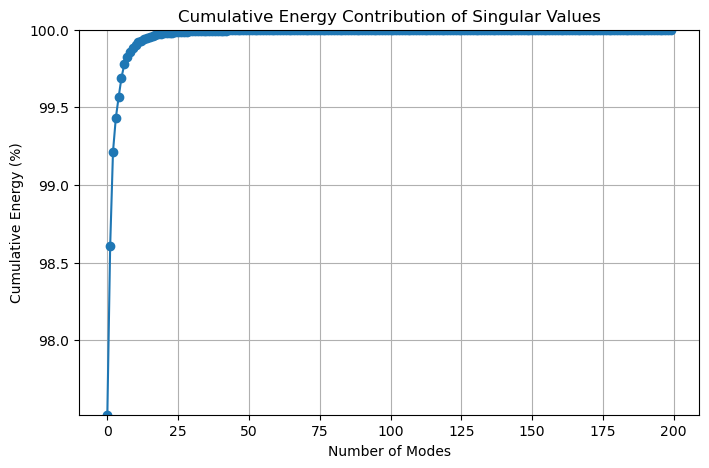

In [ ]:
plot_energy_contribution(S_nl)

In [ ]:
N_test = 10
parameters_test_non_lineaire_list = []
for i in range(N_test):
    slope = np.random.uniform(20.0, 60.0)
    position = np.random.uniform(50.0, 90.0)
    half_width = np.random.uniform(3.0, 7.0)
    D_background = 100.0
    D_fracture = 1.0
    parameters = {"slope": slope, "position": position, "half_width": half_width, "D_background": D_background, "D_fracture": D_fracture}
    parameters_test_non_lineaire_list.append(parameters)

In [ ]:
Ns_non_lineaire_range = range(0, Ns_non_lineaire+1, 10)
error_A_non_lineaire = np.zeros(len(Ns_non_lineaire_range))
time_non_linear = np.zeros(len(Ns_non_lineaire_range))


# ==========================================
# 0. TOUR DE CHAUFFE (WARM-UP)
# On force l'ordinateur à tout initialiser (FEniCS + NumPy) sur le plus gros cas pour preparer le cache et les compilations JIT, afin d'avoir des mesures de temps plus stables et représentatives lors du benchmark.
# ==========================================
print("Tour de chauffe en cours (compilation JIT et initialisation mémoire)...")
params_warmup = parameters_test_non_lineaire_list[0]
A_warmup, b_warmup = get_stiffness_and_load(params_warmup)
u_full_warmup = Function(V)
solve(A_warmup, u_full_warmup.vector(), b_warmup) # Chauffe FEniCS

r_max = Ns_non_lineaire_range[-1] # On prend le plus gros r (ex: 50)
V_r_warmup = U_nl[:, :r_max]
A_red_warmup = build_reduced_stiffness(A_warmup, V_r_warmup) # Chauffe la projection
b_red_warmup = build_reduced_load(b_warmup, V_r_warmup)
u_red_warmup = np.linalg.solve(A_red_warmup, b_red_warmup)   # Chauffe le solveur NumPy
_ = V_r_warmup.dot(u_red_warmup) + u_L_vect                  # Chauffe le produit matriciel
print("Tour de chauffe terminé ! Lancement du benchmark...")
# ==========================================
A_test_list = []
b_test_list = []
HF_sol_list = []
for i, params in enumerate(parameters_test_non_lineaire_list):
    A_test, b_test = get_stiffness_and_load(params)
    A_test_list.append(A_test)
    b_test_list.append(b_test)
    
    # Résolution Haute Fidélité (FOM) de référence
    u_full = Function(V)
    solve(A_test, u_full.vector(), b_test) 
    HF_sol_list.append(u_full)




for j, r in enumerate(tqdm(Ns_non_lineaire_range, desc="Testing ROM with non-linear snapshots")):
    for i, params in enumerate(parameters_test_non_lineaire_list):
        A_test = A_test_list[i]
        b_test = b_test_list[i]
        u_full = HF_sol_list[i]
        # ==========================================
        # DÉBUT DU CHRONO : PHASE ONLINE ROM STRICTE
        # ==========================================
        t0 = time() 

        V_r = U_nl[:, :r]
        A_red = build_reduced_stiffness(A_test, V_r)
        b_red = build_reduced_load(b_test, V_r)
        
        u_red = np.linalg.solve(A_red, b_red)
        u_approx = V_r.dot(u_red) + u_L_vect
        
        t1 = time() 
        # ==========================================
        # FIN DU CHRONO
        # ==========================================
        
        # 2. POST-TRAITEMENT ET ERREUR (Hors chrono ROM)
        u_approx_fenics = numpy_to_fenics(u_approx, V, u_L_vect)
        error_A_non_lineaire[j] += error_A_norm(u_full, u_approx_fenics, A_test)
        
        time_non_linear[j] += (t1 - t0)

    # Moyenne sur les N_test paramètres
    error_A_non_lineaire[j] /= len(parameters_test_non_lineaire_list) 
    time_non_linear[j] /= len(parameters_test_non_lineaire_list)
    
    print(f"Error in A-norm with {r} modes: {error_A_non_lineaire[j]:.4e} | Time: {time_non_linear[j]:.4e} s")

Tour de chauffe en cours (compilation JIT et initialisation mémoire)...
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Tour de chauffe terminé ! Lancement du benchmark...
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-i

Testing ROM with non-linear snapshots:   5%|▍         | 1/21 [00:00<00:03,  5.44it/s]

Error in A-norm with 0 modes: 1.0000e+00 | Time: 7.5276e-03 s


Testing ROM with non-linear snapshots:  10%|▉         | 2/21 [00:00<00:07,  2.63it/s]

Error in A-norm with 10 modes: 1.5937e-02 | Time: 4.0825e-02 s


...

Error in A-norm with 180 modes: 5.9029e-03 | Time: 2.7600e+00 s


Testing ROM with non-linear snapshots:  95%|█████████▌| 20/21 [05:31<00:27, 27.08s/it]

Error in A-norm with 190 modes: 5.8732e-03 | Time: 2.9767e+00 s


Testing ROM with non-linear snapshots: 100%|██████████| 21/21 [05:57<00:00, 17.02s/it]

Error in A-norm with 200 modes: 5.8541e-03 | Time: 2.5688e+00 s


In [ ]:
HF_compution_time_nl = 0
for i, params in enumerate(parameters_test_non_lineaire_list):
    A_test, b_test = get_stiffness_and_load(params)
    u_full = Function(V)
    t = time()
    solve(A_test, u_full.vector(), b_test)
    HF_compution_time_nl += time() - t
HF_compution_time_nl /= N_test
print(f"Average time for HF computation: {HF_compution_time_nl:.4f} seconds")

Average time for HF computation: 1.2517 seconds


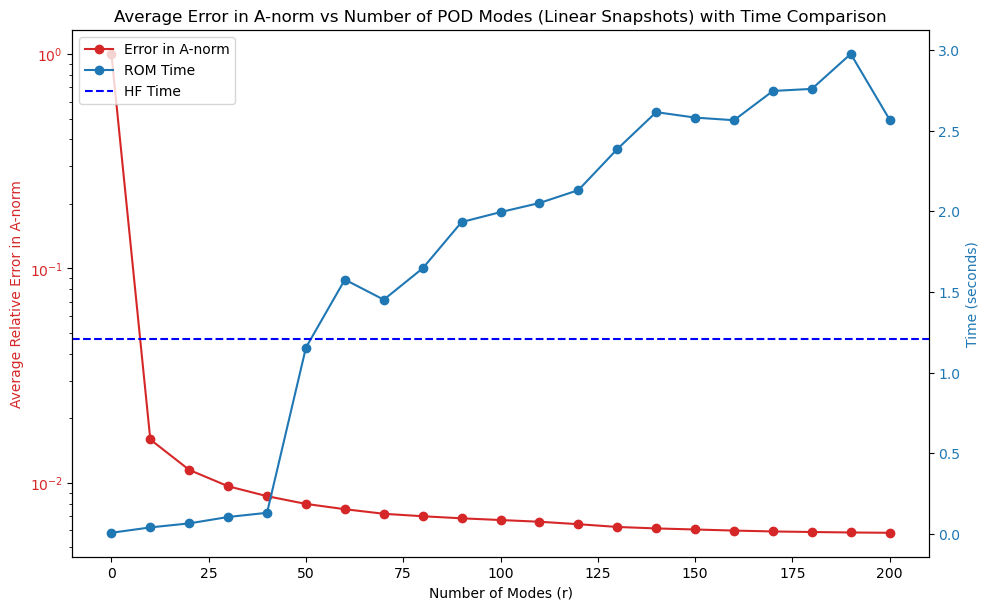

In [ ]:

# Créer la figure et l'axe principal pour l'erreur
fig, ax1 = plt.subplots(figsize=(10, 6))
# Plotter l'erreur en norme A sur l'axe principal (gauche)
color = 'tab:red'
ax1.set_xlabel('Number of Modes (r)')
ax1.set_ylabel('Average Relative Error in A-norm', color=color)
ax1.semilogy(Ns_non_lineaire_range, error_A_non_lineaire, marker='o', color=color, label='Error in A-norm')
ax1.tick_params(axis='y', labelcolor=color)
# Créer un deuxième axe y partagant la même échelle x
ax2 = ax1.twinx()
# Plotter le temps sur le deuxième axe (droite)
color = 'tab:blue'
ax2.set_ylabel('Time (seconds)', color=color)
ax2.plot(Ns_non_lineaire_range, time_non_linear, marker='o', color=color, label='ROM Time')
ax2.axhline(y=HF_compution_time, color='b', linestyle='--', label='HF Time')
ax2.tick_params(axis='y', labelcolor=color)
# Ajouter une légende
fig.tight_layout()  # Ajuster la disposition pour éviter les chevauchements
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
# Ajouter un titre
plt.title('Average Error in A-norm vs Number of POD Modes (Linear Snapshots) with Time Comparison')
# Afficher le graphique
plt.show()

évolution de la solution approchée en fonction du nombre de modes POD :


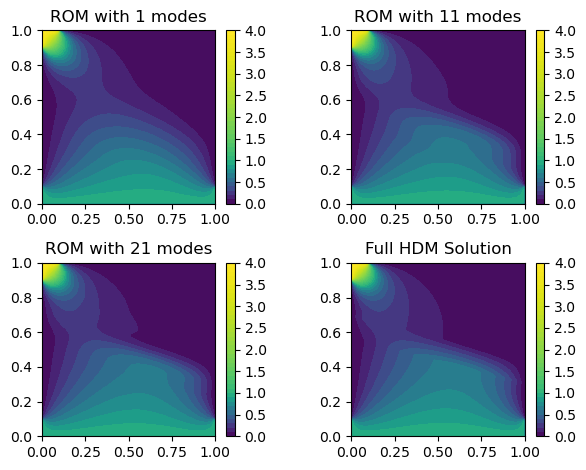

In [ ]:
print("évolution de la solution approchée en fonction du nombre de modes POD :")
for i, r in enumerate(range(1, 31, 10)):
    V_r = U_nl[:, :r]
    A_test = A_test_list[0]  # On prend le premier cas de test pour la visualisation
    b_test = b_test_list[0]  # On prend le premier cas de test pour la visualisation
    A_red = build_reduced_stiffness(A_test, V_r)
    b_red = build_reduced_load(b_test, V_r)
    u_red = np.linalg.solve(A_red, b_red)
    u_approx = V_r.dot(u_red) + u_L_vect
    u_approx_fenics = numpy_to_fenics(u_approx, V, u_L_vect)
    
    plt.subplot(2, 2, i + 1)
    p = plot(u_approx_fenics, 
          cmap="viridis", 
          norm=colors.SymLogNorm(linthresh=1e0, vmin=0.0, vmax=4.0))
    plt.title(f"ROM with {r} modes")
    plt.colorbar(p, fraction=0.046, pad=0.04)
plt.subplot(2, 2, 4)
u_full = HF_sol_list[0]  # Solution HDM de référence pour le même cas de test
p = plot(u_full, 
          cmap="viridis", 
          norm=colors.SymLogNorm(linthresh=1e0, vmin=0.0, vmax=4.0))
plt.title("Full HDM Solution")
plt.colorbar(p, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## L'EIM
Nous sommes donnés une fonction $g(·;µ) \in L∞(Ω)$ de régularité suffisante. 

Pour commencer, nous choisissons $\mu_g^1$, et définissons $S_g^1 = \{\mu_g^1\}$, $\xi_1 ≡ g(x;\mu_g^1)$, et $W_g^1 = \text{span}\{\xi_1\}$ ; nous supposons que $\xi_1 ≠ 0$. 

Ensuite, pour $M ≥ 2$, nous définissons $\mu_g^M = \arg \max_{\mu \in \Xi_g} \inf_{z \in W_g^{M-1}} \|g(·;\mu)− z\|_{L∞(Ω)}$, où $\Xi_g$ est un échantillon de paramètre suffisamment fin sur $D$. 

Nous définissons ensuite $S_g^M = S_g^{M-1} ∪ \mu_g^M$, $\xi_M = g(x;\mu_g^M)$, et $W_g^M = \text{span}\{\xi_m, 1 ≤ m ≤ M\}$ . 

Notez que, grâce à notre approximation de vérité, $\mu_g^M$ est la solution d'un programme linéaire standard.



In [521]:
def g(mu) :
    parameters = {"slope": mu[0], "position": mu[1], "half_width": mu[2], "D_background": mu[3], "D_fracture": mu[4]}
    K =get_conductivity(parameters)
    G = project(K, V)
    return G

M_max = 40

MU_MIN = [
    10.0,
    30.0,
    1.0,
    1e-6,
    1e-3
]

# --- BORNES SUPÉRIEURES (MAX) ---
MU_MAX = [
    100.0,
    90.0,
    10.0,
    1e-4,
    1e-2
]



In [522]:

from itertools import combinations


RandomPoints = np.random.rand(200, 5) * (np.array(MU_MAX) - np.array(MU_MIN)) + np.array(MU_MIN)
# 3. On transforme ça en une liste de dictionnaires exploitables par tes fonctions
D_train = [
    [
        s, 
        p, 
        hw, 
        db, 
        df
    ] 
    for s, p, hw, db, df in RandomPoints
]

print(f"Taille de l'espace d'entraînement D_train : {len(D_train)} points")

Taille de l'espace d'entraînement D_train : 200 points


In [520]:
# 1. Initialisation
N_train = len(D_train)
nb_dofs = V.dim()

print(f"Création de la Matrice des Snapshots : {N_train} paramètres x {nb_dofs} degrés de liberté.")
Snapshots_conductivite = np.zeros((N_train, nb_dofs))

# 2. La boucle de calcul (La seule partie lente de tout ton projet !)
for i, mu in enumerate(tqdm(D_train, desc="Calcul FEniCS (Phase Offline)")):
    # Appel à FEniCS
    G = g(mu)
    
    # Extraction du vecteur NumPy et stockage direct dans la ligne 'i' de la matrice
    Snapshots_conductivite[i, :] = G.vector().get_local()

print("\nTerminé ! La matrice est prête en mémoire.")
print(f"Forme de la matrice (Shape) : {Snapshots_conductivite.shape}")

Création de la Matrice des Snapshots : 200 paramètres x 160801 degrés de liberté.


Calcul FEniCS (Phase Offline):   3%|▎         | 6/200 [00:10<06:04,  1.88s/it]

Calling FFC just-in-time (JIT) compiler, this may take some time.


Calcul FEniCS (Phase Offline):   4%|▎         | 7/200 [00:13<08:05,  2.51s/it]

Calling FFC just-in-time (JIT) compiler, this may take some time.


...

Calling FFC just-in-time (JIT) compiler, this may take some time.


Calcul FEniCS (Phase Offline): 100%|█████████▉| 199/200 [20:20<00:03,  3.81s/it]

Calling FFC just-in-time (JIT) compiler, this may take some time.


Calcul FEniCS (Phase Offline): 100%|██████████| 200/200 [20:24<00:00,  6.12s/it]


Terminé ! La matrice est prête en mémoire.
Forme de la matrice (Shape) : (200, 160801)


ensuite :
$\mu_g^M = \arg \max_{\mu \in \Xi_g} \inf_{z \in W_g^{M-1}} \|g(·;\mu)− z\|_{L∞(Ω)}$


In [523]:
# 1. Norme inf ultra-rapide (Que du NumPy !)
def norm_inf_numpy(G_array, z_array):
    return np.max(np.abs(G_array - z_array))


# 2. Descente de gradient foudroyante (Que du NumPy !)
def descente_numpy(G_array, W, n, alpha=1e-3, max_iter=3, tol=1e-6):
    z = np.zeros(n)
    W_active = W[:n]
    it = 0
    
    while it < max_iter:
        z_array_actuel = z @ W_active
        erreur_actuelle = norm_inf_numpy(G_array, z_array_actuel)
        
        if erreur_actuelle <= tol:
            break
            
        grad = np.zeros(n)
        for i in range(n):
            z_plus = z.copy()
            z_plus[i] += 1e-5 
            z_plus_array = z_plus @ W_active
            
            erreur_plus = norm_inf_numpy(G_array, z_plus_array)
            grad[i] = (erreur_plus - erreur_actuelle) / 1e-5
            
        z -= alpha * grad
        it += 1
        
    return z


# 3. Projection protégée
def projection_numpy(G_array, W, n):
    # BLINDAGE ABSOLU : Si n=0, la projection est un vecteur de zéros. Point.
    if n == 0:
        return np.zeros(W.shape[1]) 
        
    coeffs = descente_numpy(G_array, W, n)
    W_active = W[:n]
    return coeffs @ W_active


# 4. La boucle principale optimisée
def recherche_mu_max_discret(W, n, D_train):
    print(f"Recherche du mu_max dans D_train avec n={n} modes...")
    err_max = -1.0
    mu_max = None
    total_mu = len(D_train)
    
    for i, mu_test in enumerate(D_train):
        # ---------------------------------------------------------
        # L'UNIQUE APPEL FENICS (C'est ici qu'on paie le prix du calcul)
        G = g(mu_test)
        G_array = G.vector().get_local()
        # ---------------------------------------------------------
        
        # Tout le reste est des maths Numpy, c'est instantané
        z_array = projection_numpy(G_array, W, n)
        erreur_actuelle = norm_inf_numpy(G_array, z_array)
        
        if erreur_actuelle > err_max:
            err_max = erreur_actuelle
            mu_max = mu_test.copy()
            
        # Affichage plus fréquent pour que tu voies que ça ne freeze pas
        if (i + 1) % 5 == 0 or i == total_mu - 1:
            print(f"  -> Progression : {i+1}/{total_mu} (Max en cours : {err_max:.2e})", end="\r")
            
    print(f"\n  -> Recherche terminée ! Pire erreur : {err_max:.2e}")
    return mu_max, err_max

Nous construisons maintenant des ensembles imbriqués de points d'interpolation $ T_M = \{t_1, \ldots, t_M\} $, pour $ 1 \leq M \leq M_{\text{max}} $. 

Nous commençons par définir $ t_1 = \arg ess\sup_{x \in \Omega} |\xi_1(x)| $, $ q_1 = \frac{\xi_1(x)}{\xi_1(t_1)} $, et $ B_{1,1} = 1 $ (nomalement argessup mais une fois discretisé on s'en fou). 

Ensuite, pour $ M = 2, \ldots, M_{\text{max}} $, nous résolvons le système linéaire $ \sum_{j=1}^{M-1} \sigma_{M-1,j} q_j(t_i) = \xi_M(t_i), \quad 1 \leq i \leq M-1$ et définissons $ r_M(x) = \xi_M(x) - \sum_{j=1}^{M-1} \sigma_{M-1,j} q_j(x) $, $ t_M = \arg ess\sup_{x \in \Omega} |r_M(x)| $, $ q_M(x) = \frac{r_M(x)}{r_M(t_M)} $, et $ B_{i,j}^M = q_j(t_i) $, pour $ 1 \leq i, j \leq M $.

In [524]:

nb_dofs = V.dim()
# On pré-alloue W avec des zéros (comme tu l'as intelligemment suggéré !)
W = np.zeros((M_max, nb_dofs))

# D_train est ta liste générée avec itertools.product()
# D_train = [...] 

S = []

Magic_Points = []


# --- BOUCLE EIM 100% NUMPY ---
for n in range(M_max):
    print(f"\n--- Recherche du mode EIM {n+1} ---")
    
    err_max = -1.0
    best_idx = -1
    best_z_array = None
    
    # 1. RECHERCHE DU PIRE PARAMÈTRE (Balayage de la matrice)
    for i in range(N_train):
        G_array = Snapshots_conductivite[i]
        
        # On projette (Rappel: utilise bien ta fonction projection_numpy optimisée !)
        z_array = projection_numpy(G_array, W, n) 
        err = norm_inf_numpy(G_array, z_array)
        
        if err > err_max:
            err_max = err
            best_idx = i
            best_z_array = z_array # On sauvegarde la projection pour ne pas la refaire
            
    # On récupère le vainqueur
    mu_star = D_train[best_idx]
    S.append(mu_star)
    print(f"Pire paramètre : {mu_star} | Erreur Max : {err_max:.2e}")
    

    # --- CALCUL DU NOUVEAU MODE & MAGIC POINT ---
    G_star_array = Snapshots_conductivite[best_idx]
    
    # 1. Calcul du résidu
    if n == 0:
        residu = G_star_array
    else:
        residu = G_star_array - best_z_array
        
    # 2. Trouver le "Magic Point" (L'index où la valeur absolue du résidu est maximale)
    magic_point = np.argmax(np.abs(residu))
    Magic_Points.append(magic_point)
    print(f"Magic Point trouvé à l'index spatial : {magic_point}")
    
    # 3. Normaliser le résidu par sa valeur au Magic Point
    nouveau_mode = residu / residu[magic_point]
    
    # 4. Ajouter à la base W
    W[n, :] = nouveau_mode

print("\n🚀 Algorithme EIM terminé avec succès !")



--- Recherche du mode EIM 1 ---
Pire paramètre : [18.113196674339257, 56.04601119922364, 9.255211912501823, 9.494128721003954e-05, 0.0060899224261098325] | Erreur Max : 1.74e-02
Magic Point trouvé à l'index spatial : 160135

--- Recherche du mode EIM 2 ---
Pire paramètre : [96.64008353291466, 67.44502426985677, 5.0025935504813575, 2.1831347073753697e-05, 0.004585570295004608] | Erreur Max : 1.73e-02
Magic Point trouvé à l'index spatial : 139891

--- Recherche du mode EIM 3 ---
Pire paramètre : [18.740469818503392, 85.8821086701939, 9.550544092202594, 2.664137088524662e-05, 0.0058512694357095605] | Erreur Max : 1.69e-02
Magic Point trouvé à l'index spatial : 2145

--- Recherche du mode EIM 4 ---
Pire paramètre : [76.85131615900288, 52.78267531296414, 8.942502669217271, 9.88673590408772e-05, 0.002056845357891064] | Erreur Max : 1.69e-02
Magic Point trouvé à l'index spatial : 157716

--- Recherche du mode EIM 5 ---
Pire paramètre : [30.119491075036166, 50.01495204128303, 5.66427685467823

[[1.81131967e+01 5.60460112e+01 9.25521191e+00 9.49412872e-05
  6.08992243e-03]
 [9.66400835e+01 6.74450243e+01 5.00259355e+00 2.18313471e-05
  4.58557030e-03]
 [1.87404698e+01 8.58821087e+01 9.55054409e+00 2.66413709e-05
  5.85126944e-03]
 [7.68513162e+01 5.27826753e+01 8.94250267e+00 9.88673590e-05
  2.05684536e-03]
 [3.01194911e+01 5.00149520e+01 5.66427685e+00 3.23072053e-05
  3.41624618e-03]
 [3.20404766e+01 8.69465441e+01 3.32049341e+00 7.20722438e-05
  8.26031559e-03]
 [4.25895011e+01 5.96490238e+01 4.15329549e+00 8.63100972e-05
  1.49221112e-03]
 [9.09461794e+01 6.83572899e+01 4.51424571e+00 6.97063281e-05
  6.76166771e-03]
 [3.40777390e+01 8.66138293e+01 3.05483708e+00 8.17061642e-05
  8.46404367e-03]
 [8.83815862e+01 5.91798888e+01 4.14959480e+00 1.77428686e-05
  6.72735177e-03]
 [4.48701705e+01 8.21008569e+01 5.68825667e+00 3.83999652e-06
  4.00440438e-03]
 [5.00587950e+01 3.59544475e+01 9.87235006e+00 3.59408610e-05
  8.17720484e-03]
 [3.89223928e+01 5.73724451e+01 2.581610

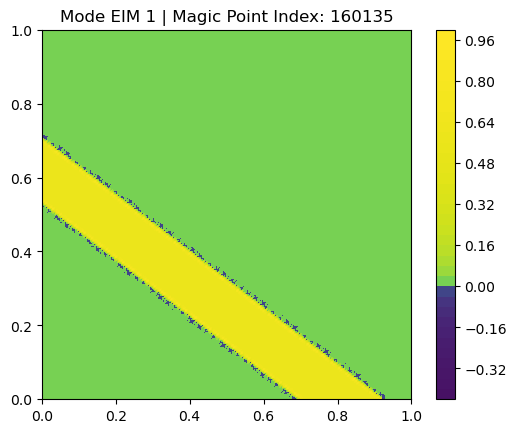

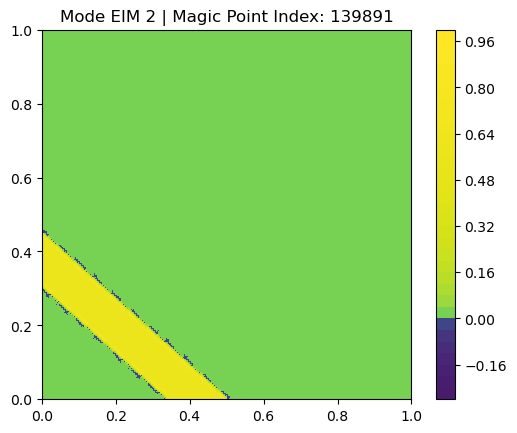

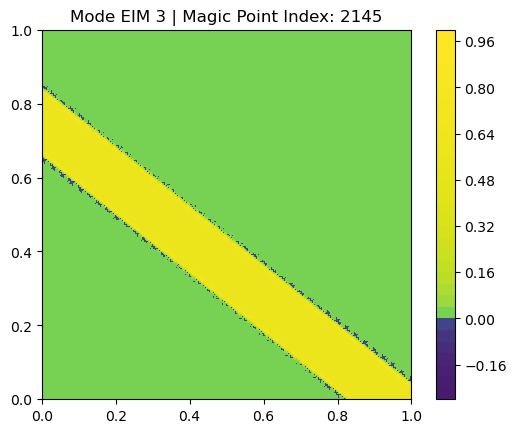

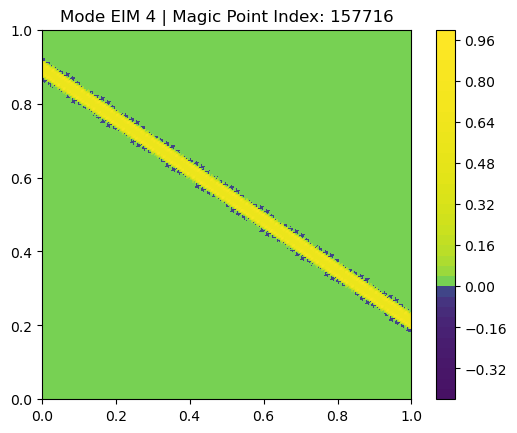

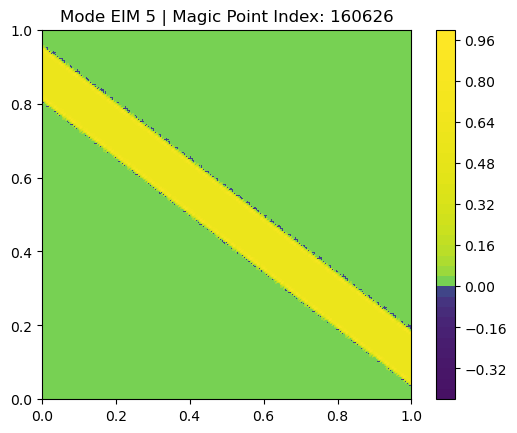

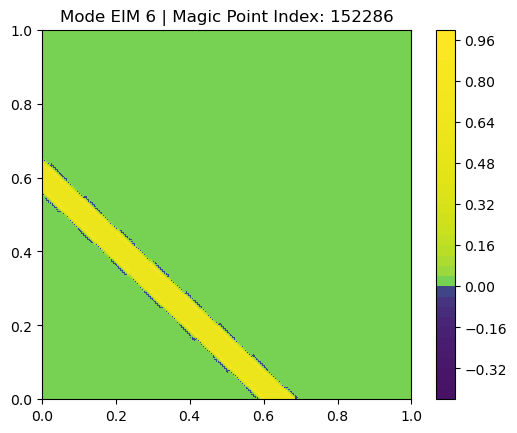

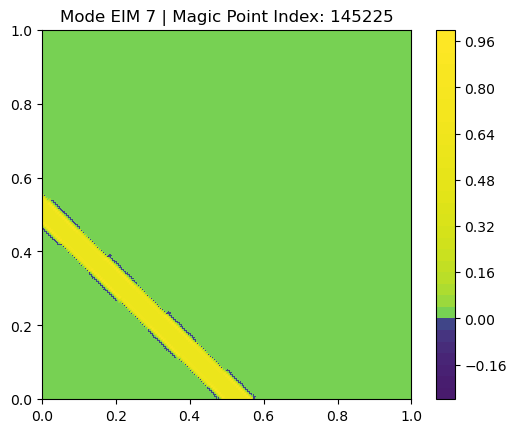

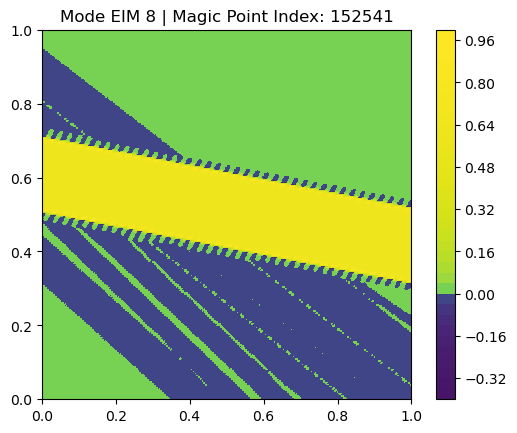

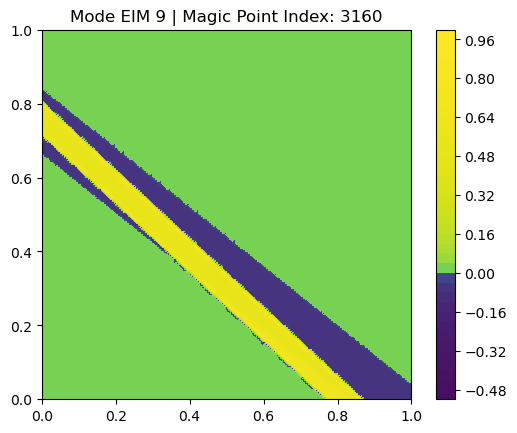

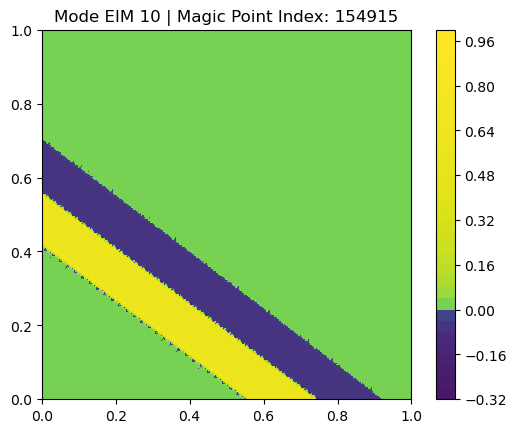

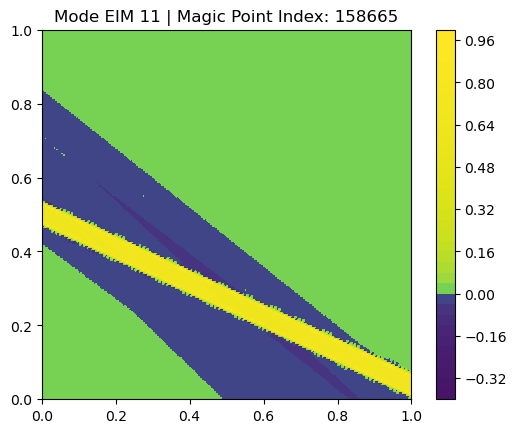

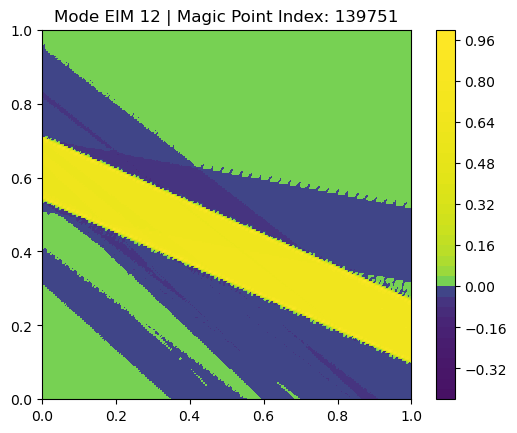

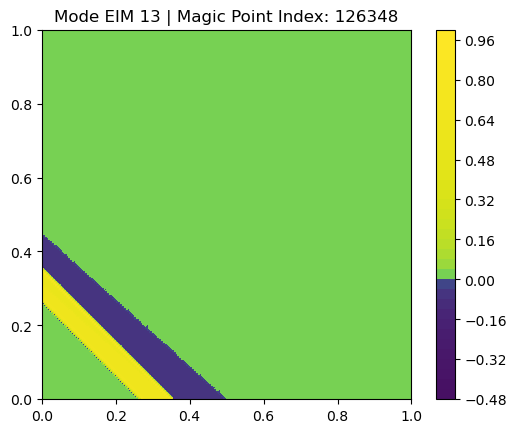

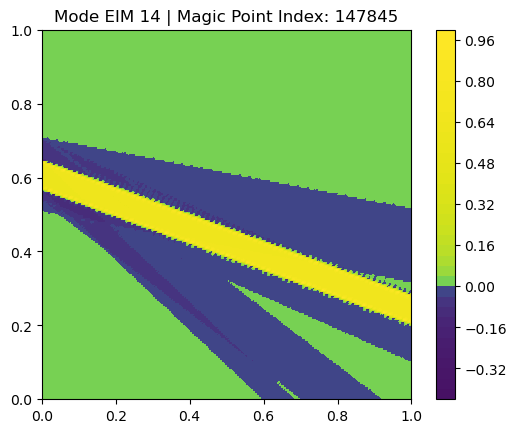

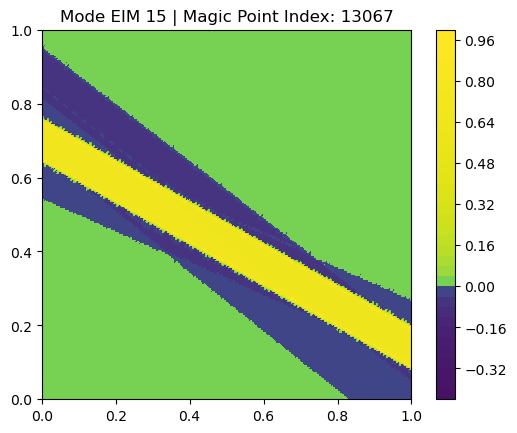

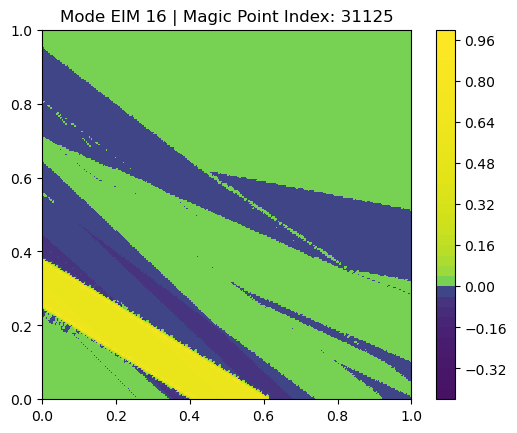

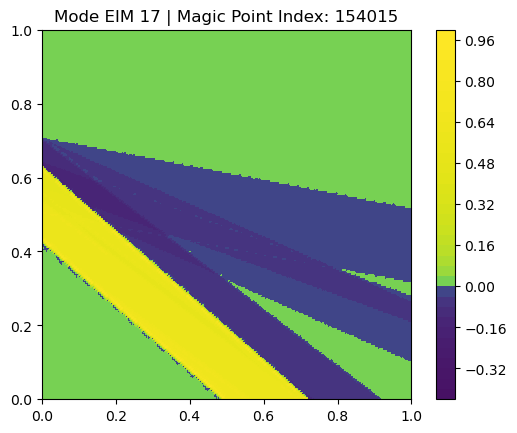

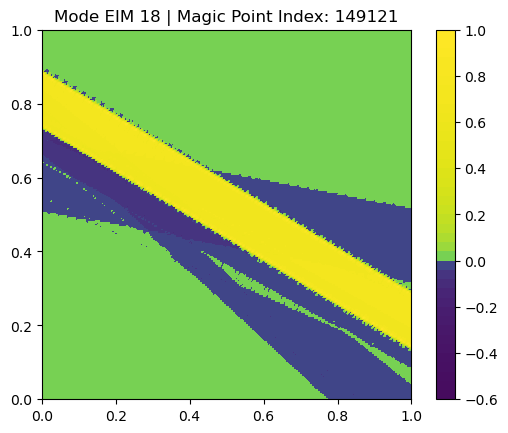

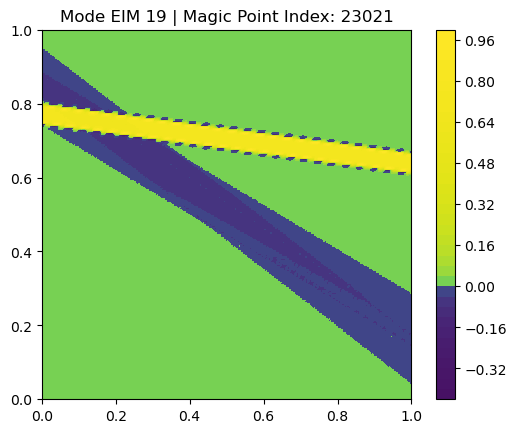

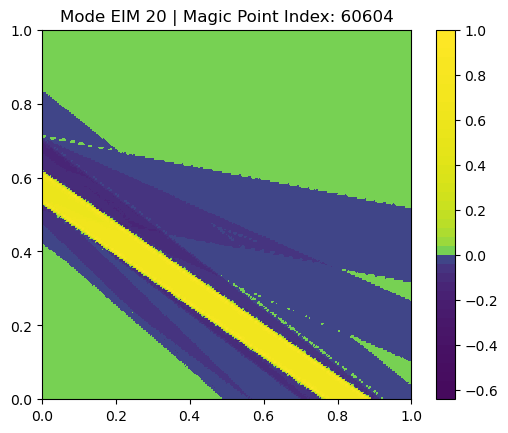

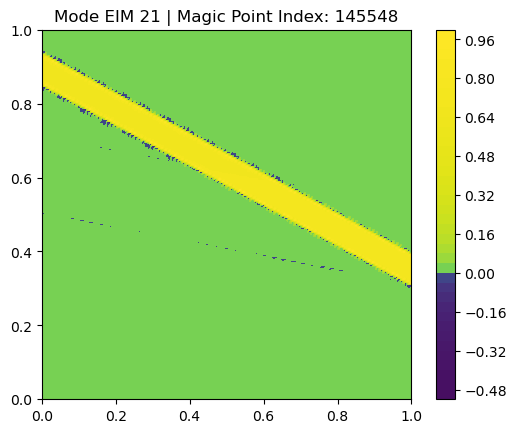

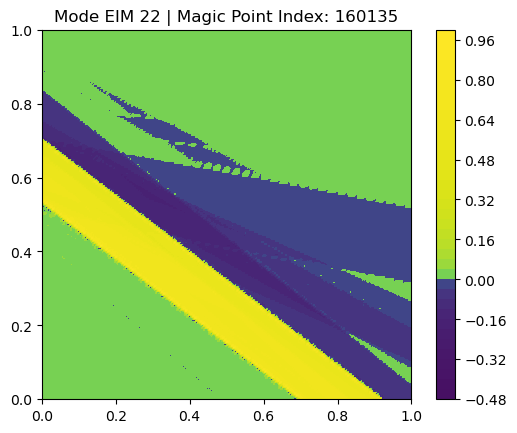

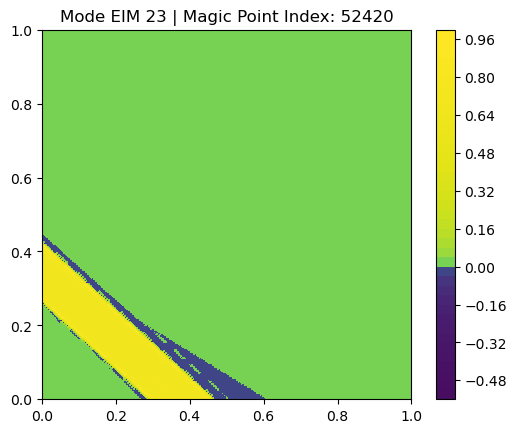

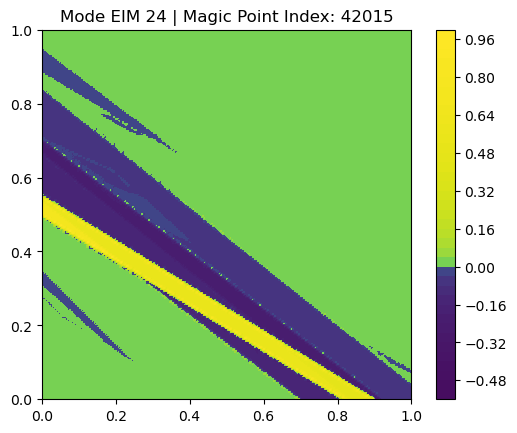

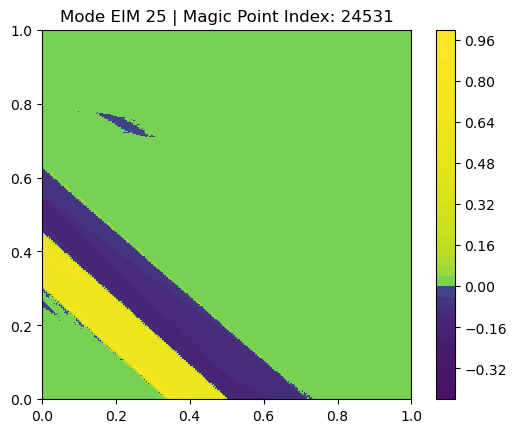

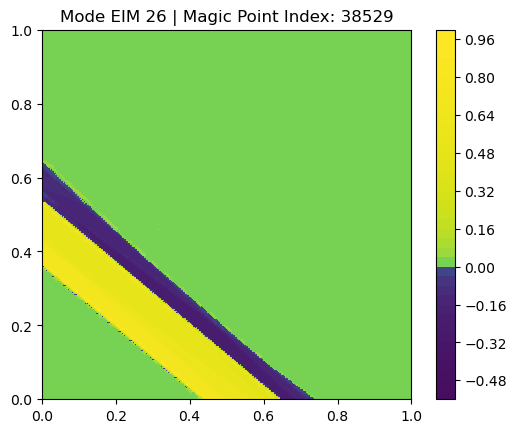

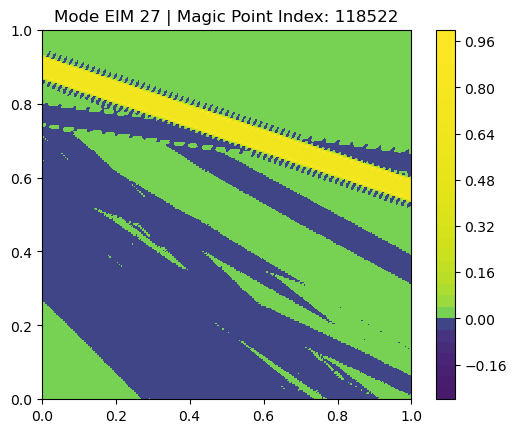

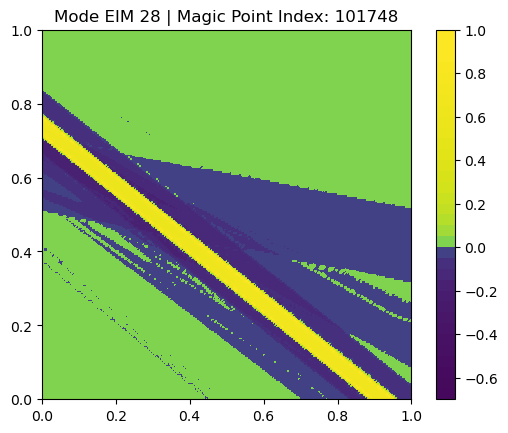

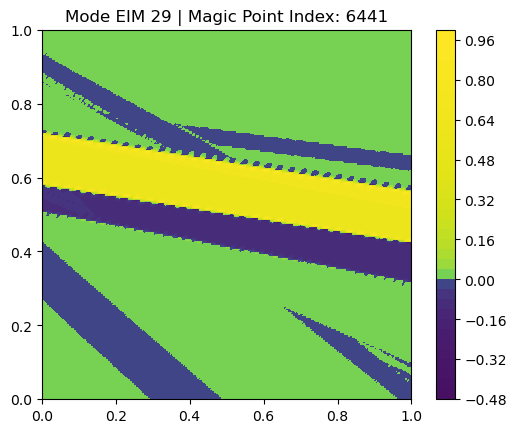

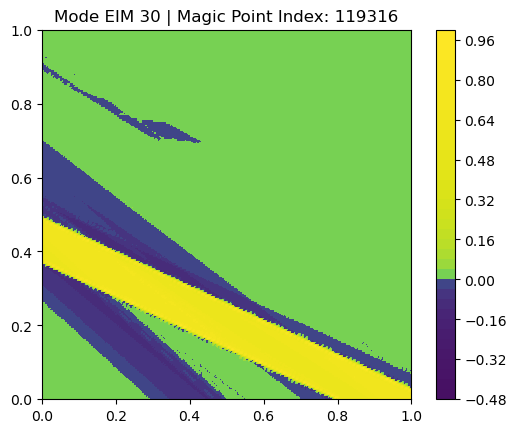

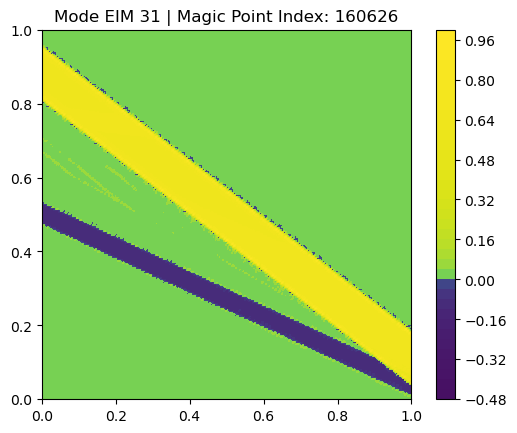

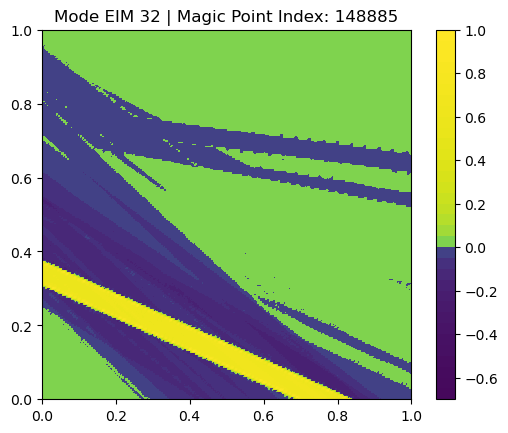

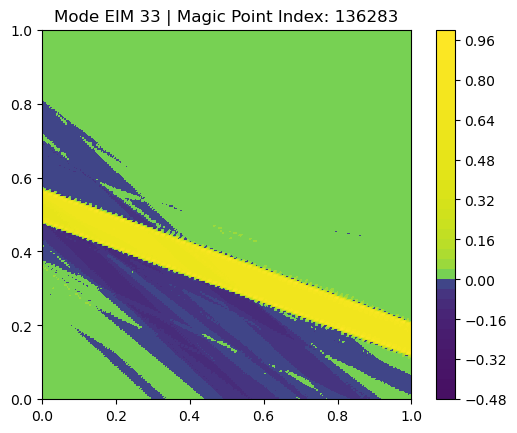

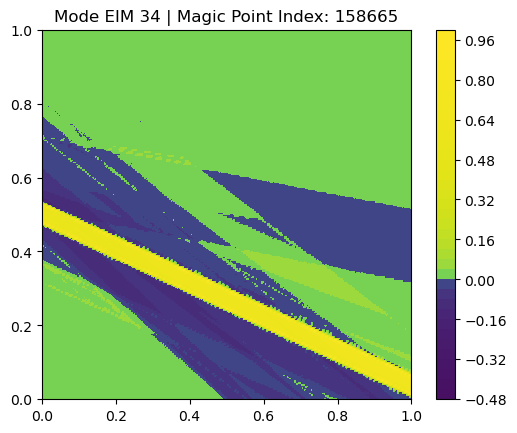

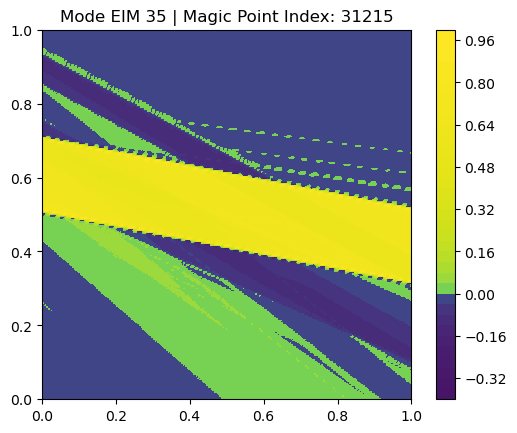

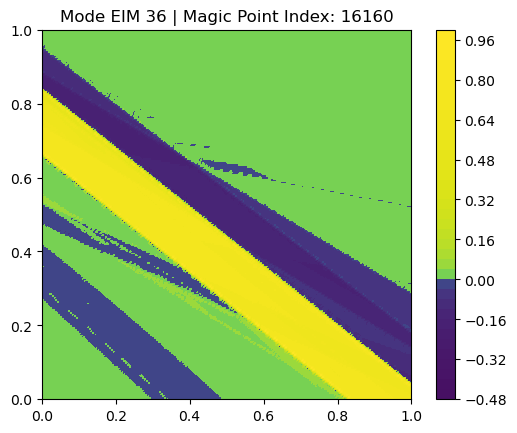

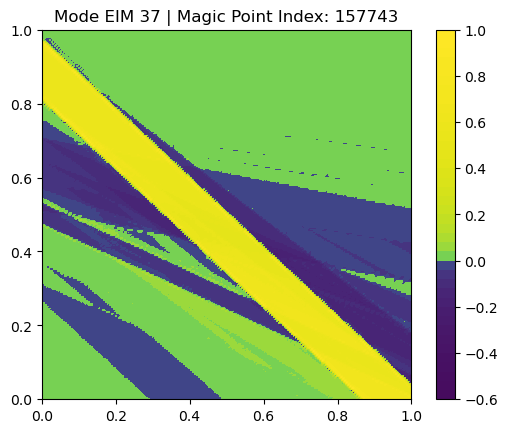

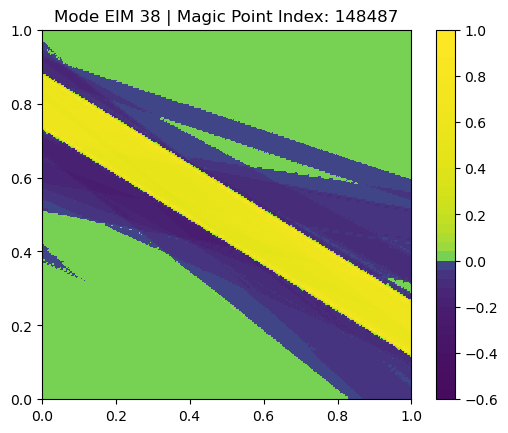

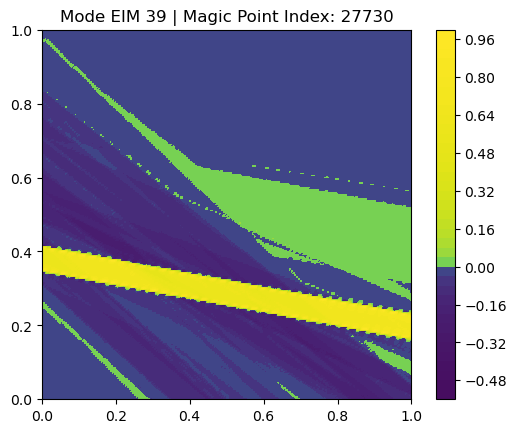

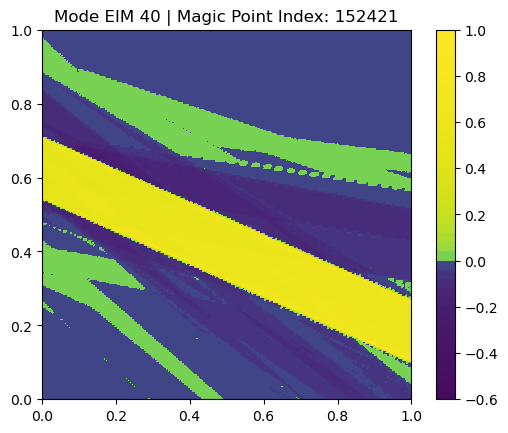

In [525]:
print(np.array(S))
print(np.array(Magic_Points))
# Visualisation des modes EIM
for i in range(M_max):
    mode_fenics = numpy_to_fenics_param(W[i, :], V)
    plt.figure()
    p = plot(mode_fenics, 
             cmap="viridis", 
             norm=colors.SymLogNorm(linthresh=1e-3, vmin=-1.0, vmax=1.0))
    plt.colorbar(p)
    plt.title(f"Mode EIM {i+1} | Magic Point Index: {Magic_Points[i]}")
    plt.show()